# Machine Learning Classification Benchmark
## Iris and Wine Datasets

### Objective
Compare multiple supervised machine learning algorithms on the
Iris and Wine datasets and identify the best-performing model using
cross-validation and hyperparameter optimization.

### Models
- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

### Optimization
- Stratified K-Fold Cross Validation
- GridSearchCV
- Hyperparameter tuning

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs(
    "/kaggle/working/results/confusion_matrices",
    exist_ok=True
)
os.makedirs(
    "/kaggle/working/results/decision_trees",
    exist_ok=True
)

print("Output directories created.")

Output directories created.


In [3]:
# ============================================================
# LOAD DATASETS
# ============================================================

iris = load_iris()
wine = load_wine()

datasets = {
    "Iris": iris,
    "Wine": wine
}

for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Samples :", data.data.shape[0])
    print("Features:", data.data.shape[1])
    print("Classes :", len(data.target_names))

    print("\nClass names:")
    print(data.target_names)

    print("\nFeature names:")
    print(data.feature_names)

    print()

Iris
Samples : 150
Features: 4
Classes : 3

Class names:
['setosa' 'versicolor' 'virginica']

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Wine
Samples : 178
Features: 13
Classes : 3

Class names:
['class_0' 'class_1' 'class_2']

Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']



In [4]:
# ============================================================
# CREATE DATAFRAMES
# ============================================================

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df["target"] = iris.target
iris_df["target_name"] = iris.target_names[iris.target]

wine_df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

wine_df["target"] = wine.target
wine_df["target_name"] = wine.target_names[wine.target]

print("Iris Dataset")
display(iris_df.head())

print("\nWine Dataset")
display(wine_df.head())

Iris Dataset


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Wine Dataset


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [5]:
# ============================================================
# BASIC DATA ANALYSIS
# ============================================================

for name, df in {
    "Iris": iris_df,
    "Wine": wine_df
}.items():

    print("=" * 70)
    print(f"{name} DATASET")
    print("=" * 70)

    print("\nShape:")
    print(df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nClass Distribution:")
    print(df["target_name"].value_counts())

    print("\nStatistics:")
    display(df.describe())

Iris DATASET

Shape:
(150, 6)

Missing Values:
0

Duplicate Rows:
1

Class Distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Wine DATASET

Shape:
(178, 15)

Missing Values:
0

Duplicate Rows:
0

Class Distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Statistics:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


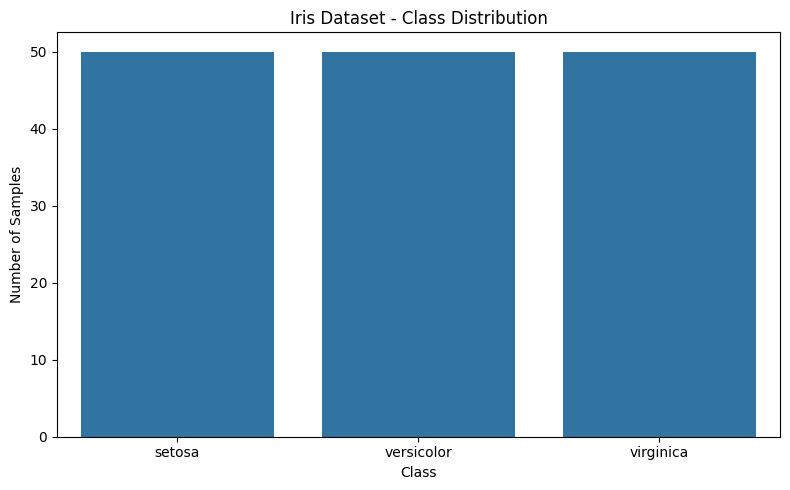

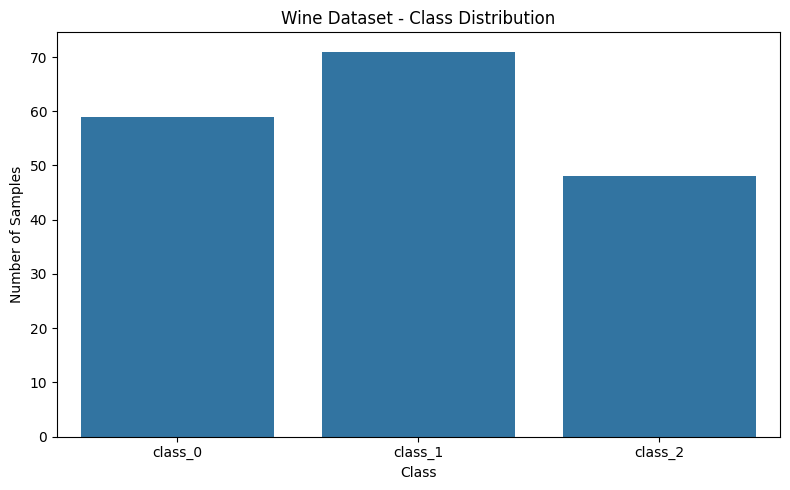

In [6]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

for name, df in {
    "Iris": iris_df,
    "Wine": wine_df
}.items():

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x="target_name"
    )

    plt.title(
        f"{name} Dataset - Class Distribution"
    )

    plt.xlabel("Class")
    plt.ylabel("Number of Samples")

    plt.tight_layout()
    plt.show()

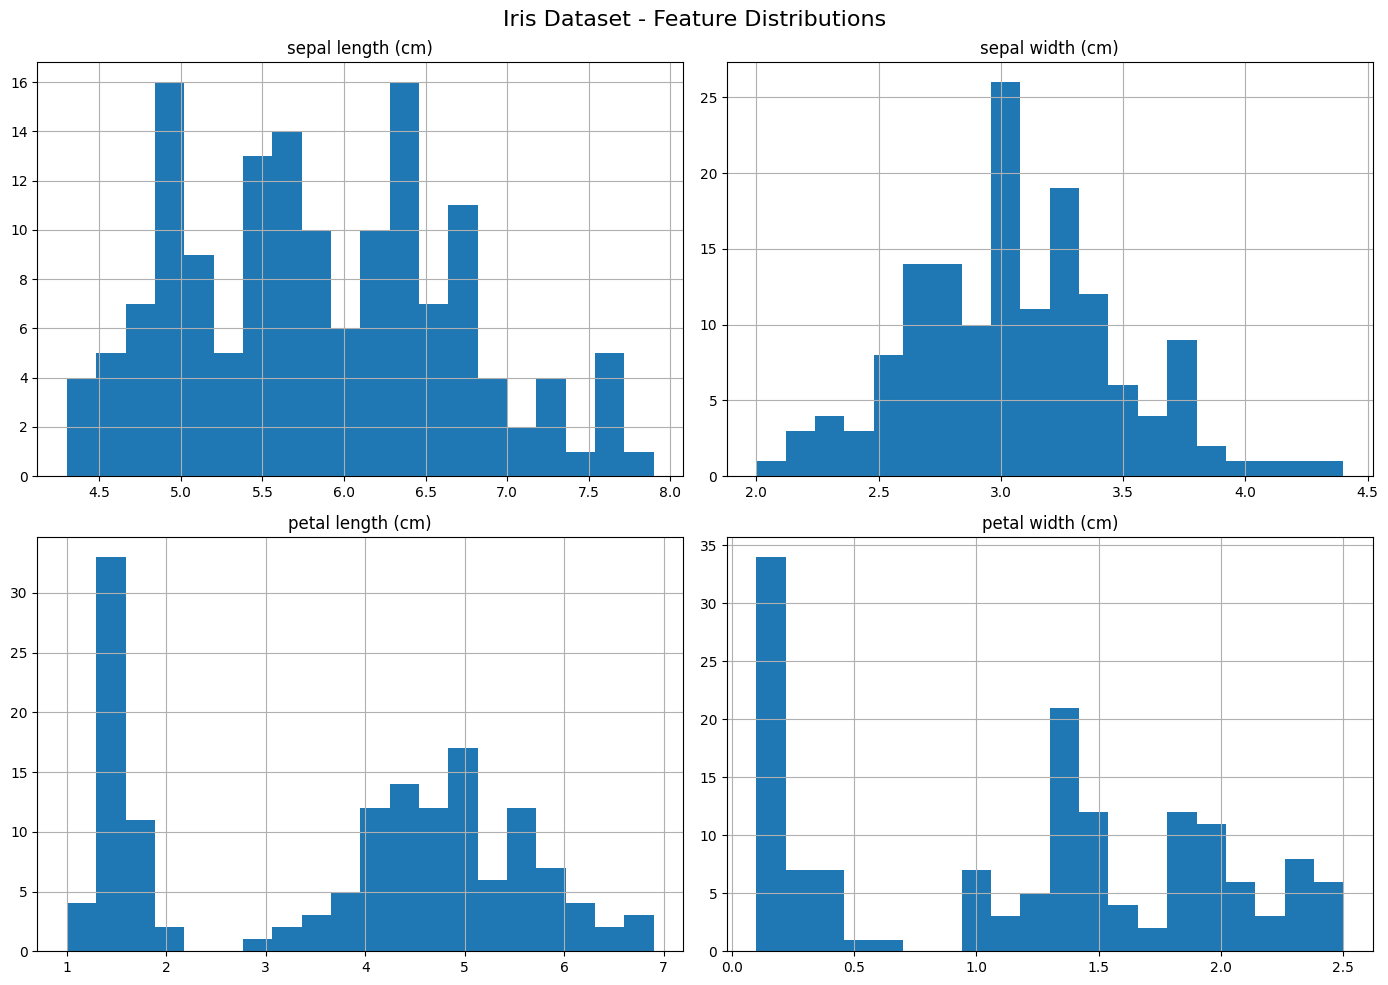

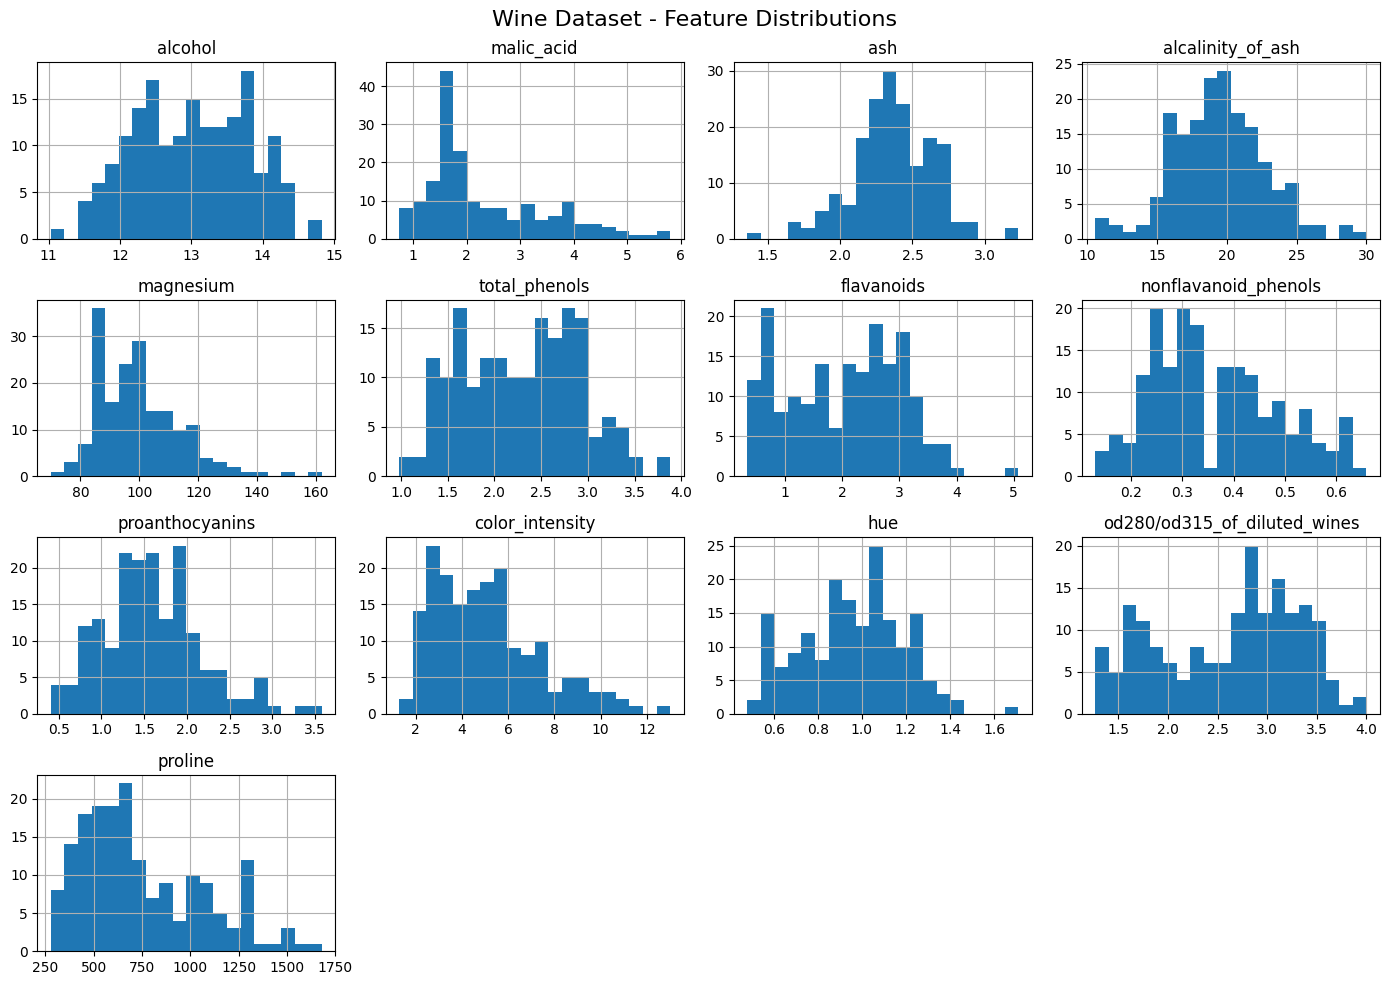

In [7]:
# ============================================================
# FEATURE DISTRIBUTION
# ============================================================

for name, df in {
    "Iris": iris_df,
    "Wine": wine_df
}.items():

    df.drop(
        columns=["target", "target_name"]
    ).hist(
        figsize=(14, 10),
        bins=20
    )

    plt.suptitle(
        f"{name} Dataset - Feature Distributions",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

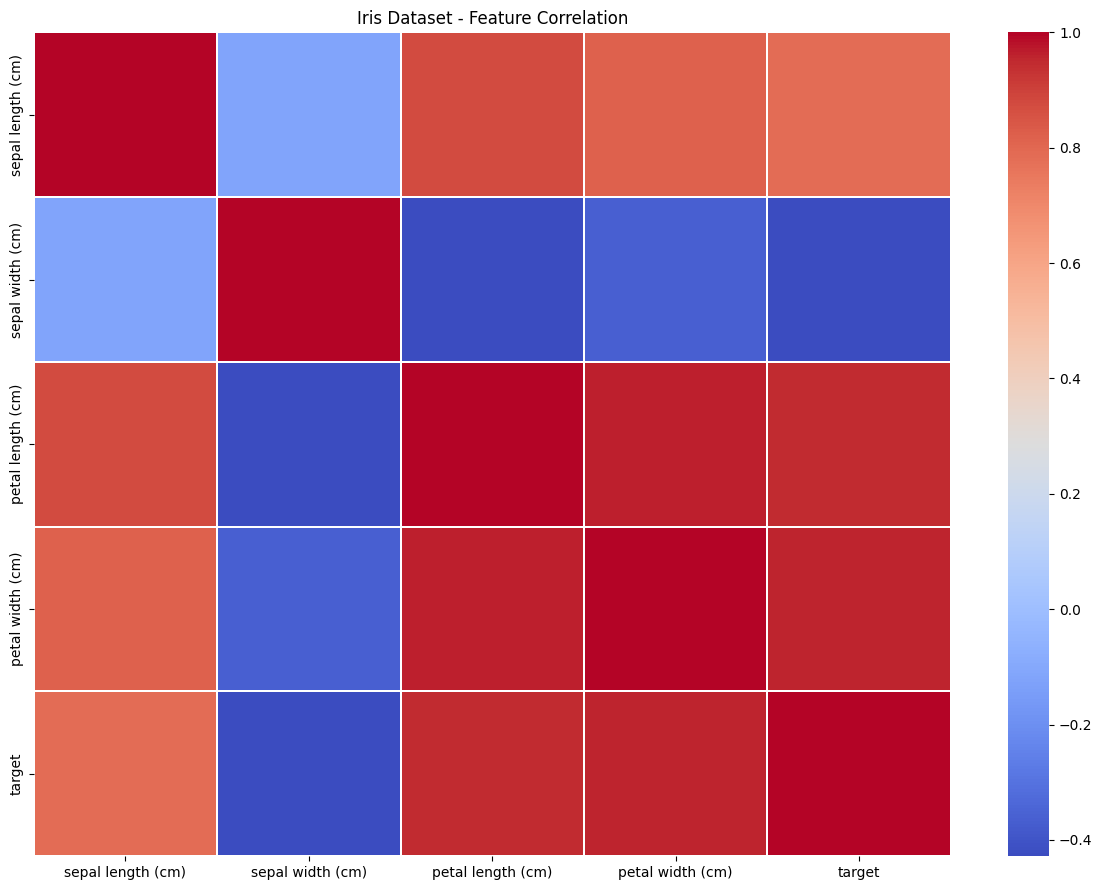

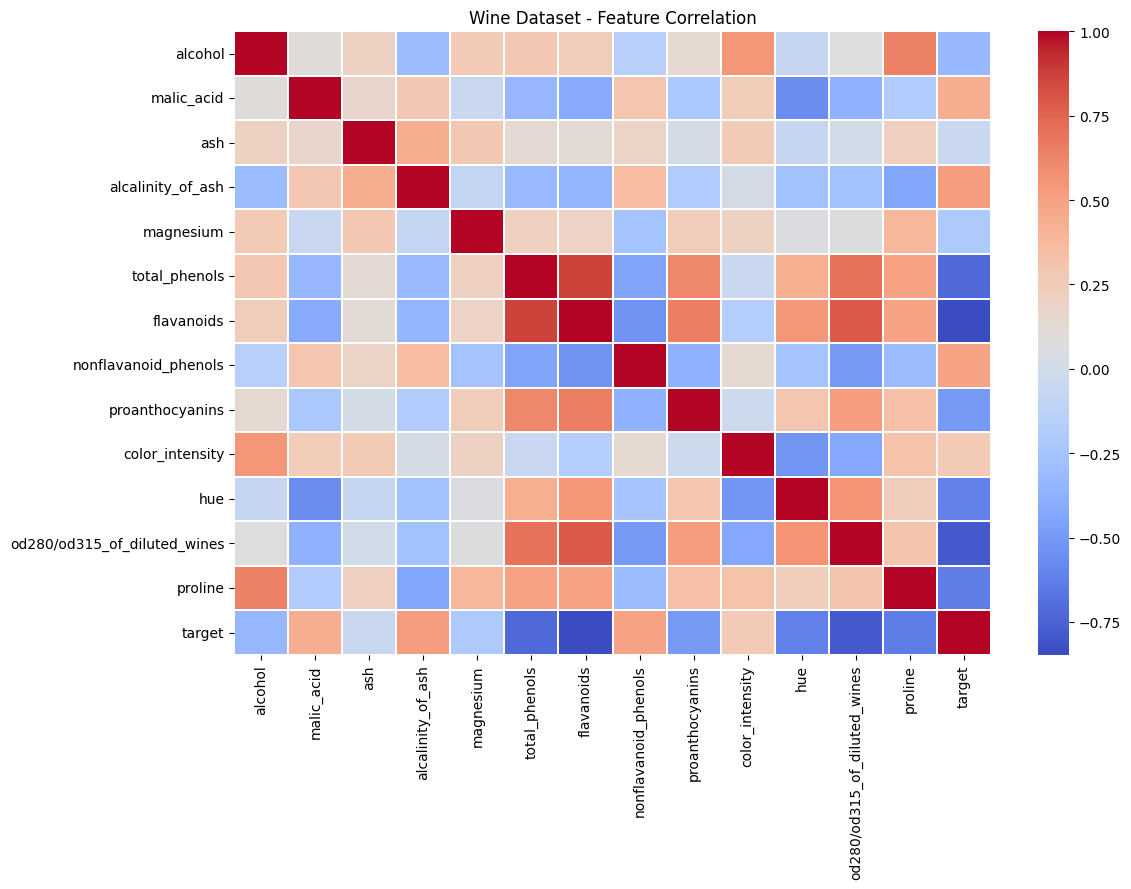

In [8]:
# ============================================================
# CORRELATION HEATMAPS
# ============================================================

for name, df in {
    "Iris": iris_df,
    "Wine": wine_df
}.items():

    plt.figure(
        figsize=(12, 9)
    )

    sns.heatmap(
        df.drop(
            columns=["target_name"]
        ).corr(),
        annot=False,
        cmap="coolwarm",
        linewidths=0.2
    )

    plt.title(
        f"{name} Dataset - Feature Correlation"
    )

    plt.tight_layout()
    plt.show()

In [9]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

data_splits = {}

for name, data in datasets.items():

    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    data_splits[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(
        f"{name}: "
        f"Train = {X_train.shape[0]}, "
        f"Test = {X_test.shape[0]}"
    )

Iris: Train = 120, Test = 30
Wine: Train = 142, Test = 36


In [10]:
# ============================================================
# ALL MACHINE LEARNING MODELS
# ============================================================

models = {

    # --------------------------------------------------------
    # 1. Logistic Regression
    # --------------------------------------------------------

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    # --------------------------------------------------------
    # 2. K-Nearest Neighbors
    # --------------------------------------------------------

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            KNeighborsClassifier()
        )
    ]),

    # --------------------------------------------------------
    # 3. Gaussian Naive Bayes
    # --------------------------------------------------------

    "Gaussian Naive Bayes": GaussianNB(),

    # --------------------------------------------------------
    # 4. Support Vector Machine
    # --------------------------------------------------------

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            SVC()
        )
    ]),

    # --------------------------------------------------------
    # 5. Decision Tree
    # --------------------------------------------------------

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    # --------------------------------------------------------
    # 6. Random Forest
    # --------------------------------------------------------

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # 7. Gradient Boosting
    # --------------------------------------------------------

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}


print("Models loaded:")
for i, model_name in enumerate(models, 1):
    print(f"{i}. {model_name}")

Models loaded:
1. Logistic Regression
2. KNN
3. Gaussian Naive Bayes
4. SVM
5. Decision Tree
6. Random Forest
7. Gradient Boosting


In [11]:
# ============================================================
# HYPERPARAMETER SEARCH SPACES
# ============================================================

param_grids = {

    # --------------------------------------------------------
    # Logistic Regression
    # --------------------------------------------------------

    "Logistic Regression": {

        "model__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "model__solver": [
            "lbfgs",
            "liblinear"
        ]
    },


    # --------------------------------------------------------
    # KNN
    # --------------------------------------------------------

    "KNN": {

        "model__n_neighbors": [
            3,
            5,
            7,
            9,
            11,
            13,
            15
        ],

        "model__weights": [
            "uniform",
            "distance"
        ],

        "model__metric": [
            "euclidean",
            "manhattan"
        ]
    },


    # --------------------------------------------------------
    # Gaussian Naive Bayes
    # --------------------------------------------------------

    "Gaussian Naive Bayes": {

        "var_smoothing": [
            1e-12,
            1e-11,
            1e-10,
            1e-9,
            1e-8,
            1e-7
        ]
    },


    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------

    "SVM": {

        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__gamma": [
            "scale",
            0.001,
            0.01,
            0.1,
            1
        ],

        "model__kernel": [
            "rbf",
            "linear"
        ]
    },


    # --------------------------------------------------------
    # Decision Tree
    # --------------------------------------------------------

    "Decision Tree": {

        "criterion": [
            "gini",
            "entropy",
            "log_loss"
        ],

        "max_depth": [
            None,
            2,
            3,
            4,
            5,
            6,
            8,
            10
        ],

        "min_samples_split": [
            2,
            5,
            10
        ],

        "min_samples_leaf": [
            1,
            2,
            4
        ]
    },


    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    "Random Forest": {

        "n_estimators": [
            100,
            200,
            300
        ],

        "max_depth": [
            None,
            5,
            10,
            15
        ],

        "min_samples_split": [
            2,
            5
        ],

        "min_samples_leaf": [
            1,
            2
        ],

        "max_features": [
            "sqrt",
            "log2"
        ]
    },


    # --------------------------------------------------------
    # Gradient Boosting
    # --------------------------------------------------------

    "Gradient Boosting": {

        "n_estimators": [
            50,
            100,
            200
        ],

        "learning_rate": [
            0.01,
            0.05,
            0.1,
            0.2
        ],

        "max_depth": [
            2,
            3,
            4
        ],

        "subsample": [
            0.8,
            1.0
        ]
    }
}


print("Hyperparameter grids created.")

Hyperparameter grids created.


In [12]:
# ============================================================
# STRATIFIED K-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Stratified Cross Validation configured.")

5-Fold Stratified Cross Validation configured.


In [13]:
# ============================================================
# GRIDSEARCHCV - ALL MODELS + BOTH DATASETS
# ============================================================

grid_results = []
best_models = {}

for dataset_name in datasets:

    print("\n")
    print("=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)

    X_train = data_splits[dataset_name]["X_train"]
    y_train = data_splits[dataset_name]["y_train"]

    for model_name in models:

        print(
            f"\nRunning GridSearchCV: "
            f"{dataset_name} | {model_name}"
        )

        grid = GridSearchCV(

            estimator=models[model_name],

            param_grid=param_grids[model_name],

            cv=cv,

            scoring="accuracy",

            n_jobs=-1,

            return_train_score=True
        )

        grid.fit(
            X_train,
            y_train
        )

        # Store best model
        best_models[
            f"{dataset_name}_{model_name}"
        ] = grid.best_estimator_

        # Store results
        grid_results.append({

            "Dataset":
                dataset_name,

            "Model":
                model_name,

            "Best CV Accuracy":
                grid.best_score_,

            "Best Parameters":
                grid.best_params_
        })

        print(
            f"Best CV Accuracy: "
            f"{grid.best_score_ * 100:.2f}%"
        )

        print(
            f"Best Parameters: "
            f"{grid.best_params_}"
        )


grid_results_df = pd.DataFrame(
    grid_results
)

print("\n")
print("=" * 80)
print("GRID SEARCH COMPLETED")
print("=" * 80)



DATASET: Iris

Running GridSearchCV: Iris | Logistic Regression
Best CV Accuracy: 96.67%
Best Parameters: {'model__C': 10, 'model__solver': 'lbfgs'}

Running GridSearchCV: Iris | KNN
Best CV Accuracy: 96.67%
Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}

Running GridSearchCV: Iris | Gaussian Naive Bayes
Best CV Accuracy: 95.00%
Best Parameters: {'var_smoothing': 1e-12}

Running GridSearchCV: Iris | SVM
Best CV Accuracy: 97.50%
Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Running GridSearchCV: Iris | Decision Tree
Best CV Accuracy: 95.83%
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Running GridSearchCV: Iris | Random Forest
Best CV Accuracy: 96.67%
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Running GridSearchCV: Iris | Gradient Boosting
Best

In [14]:
# ============================================================
# FINAL TEST SET EVALUATION
# ============================================================

final_results = []

predictions = {}

for dataset_name in datasets:

    X_test = data_splits[dataset_name]["X_test"]
    y_test = data_splits[dataset_name]["y_test"]

    for model_name in models:

        key = (
            f"{dataset_name}_{model_name}"
        )

        model = best_models[key]

        y_pred = model.predict(
            X_test
        )

        predictions[key] = y_pred

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        final_results.append({

            "Dataset":
                dataset_name,

            "Model":
                model_name,

            "CV Accuracy":
                grid_results_df[
                    (
                        grid_results_df["Dataset"]
                        == dataset_name
                    )
                    &
                    (
                        grid_results_df["Model"]
                        == model_name
                    )
                ]["Best CV Accuracy"].values[0],

            "Test Accuracy":
                accuracy,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1 Score":
                f1
        })


results_df = pd.DataFrame(
    final_results
)

results_df = results_df.sort_values(
    by=[
        "Dataset",
        "Test Accuracy"
    ],
    ascending=[
        True,
        False
    ]
)

display(
    results_df.style.format({
        "CV Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)

,Dataset,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Iris,Logistic Regression,96.67%,100.00%,100.00%,100.00%,100.00%
2,Iris,Gaussian Naive Bayes,95.00%,96.67%,96.97%,96.67%,96.66%
4,Iris,Decision Tree,95.83%,96.67%,96.97%,96.67%,96.66%
5,Iris,Random Forest,96.67%,96.67%,96.97%,96.67%,96.66%
6,Iris,Gradient Boosting,96.67%,96.67%,96.97%,96.67%,96.66%
1,Iris,KNN,96.67%,93.33%,94.44%,93.33%,93.27%
3,Iris,SVM,97.50%,93.33%,93.33%,93.33%,93.33%
8,Wine,KNN,97.88%,100.00%,100.00%,100.00%,100.00%
11,Wine,Decision Tree,90.25%,100.00%,100.00%,100.00%,100.00%
12,Wine,Random Forest,97.91%,100.00%,100.00%,100.00%,100.00%


In [15]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

for dataset_name, dataset in datasets.items():

    print("\n")
    print("=" * 80)
    print(f"{dataset_name} - CLASSIFICATION REPORTS")
    print("=" * 80)

    y_test = data_splits[dataset_name]["y_test"]

    for model_name in models:

        key = (
            f"{dataset_name}_{model_name}"
        )

        y_pred = predictions[key]

        print("\n")
        print("-" * 70)
        print(model_name)
        print("-" * 70)

        print(
            classification_report(
                y_test,
                y_pred,
                target_names=dataset.target_names,
                zero_division=0
            )
        )



Iris - CLASSIFICATION REPORTS


----------------------------------------------------------------------
Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



----------------------------------------------------------------------
KNN
----------------------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   

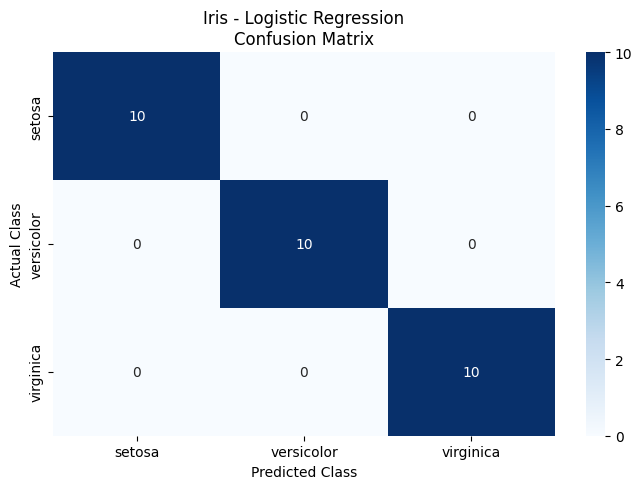

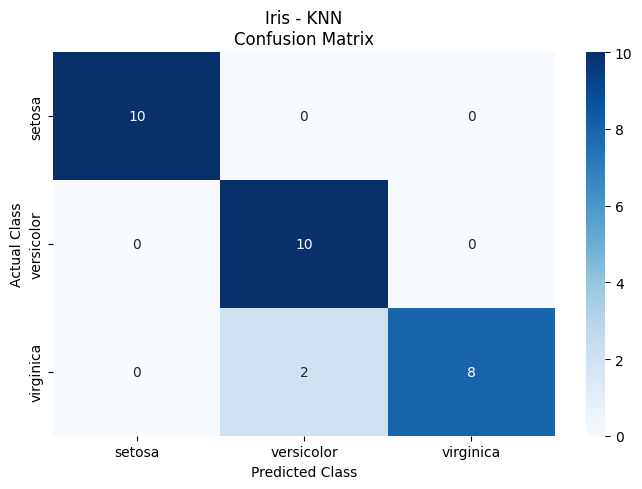

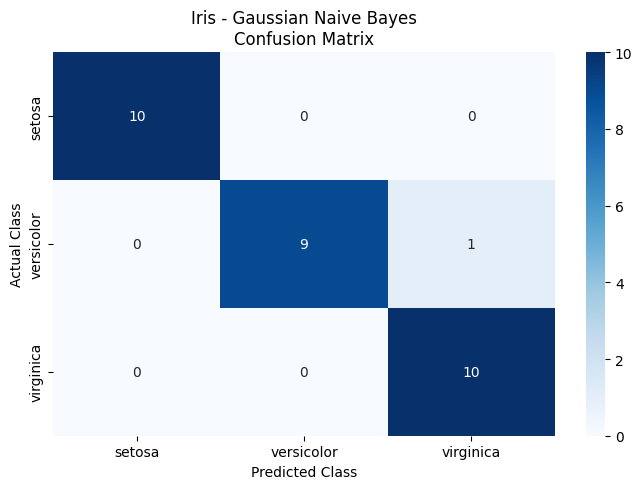

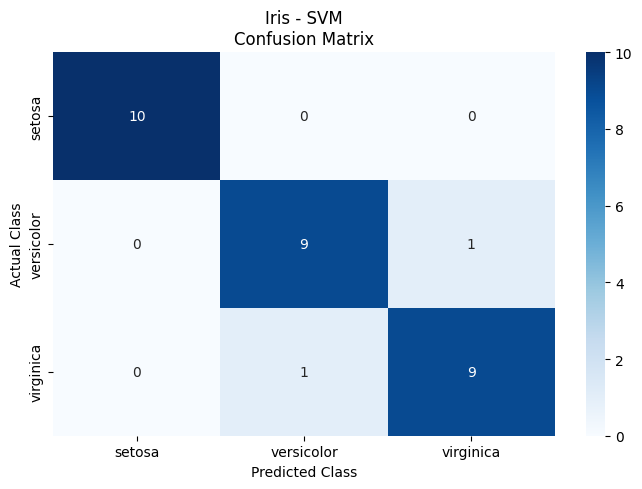

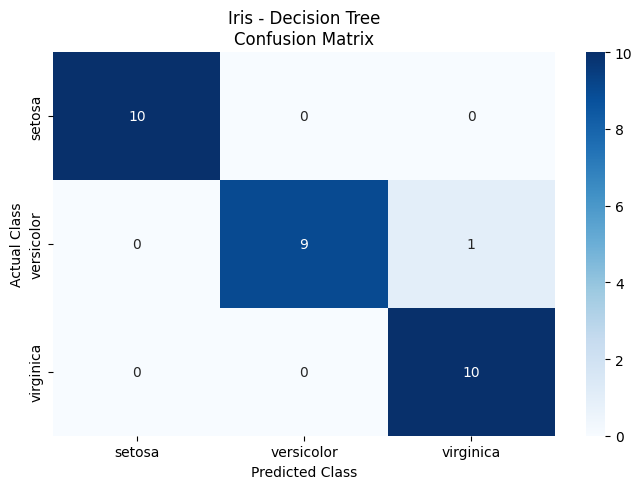

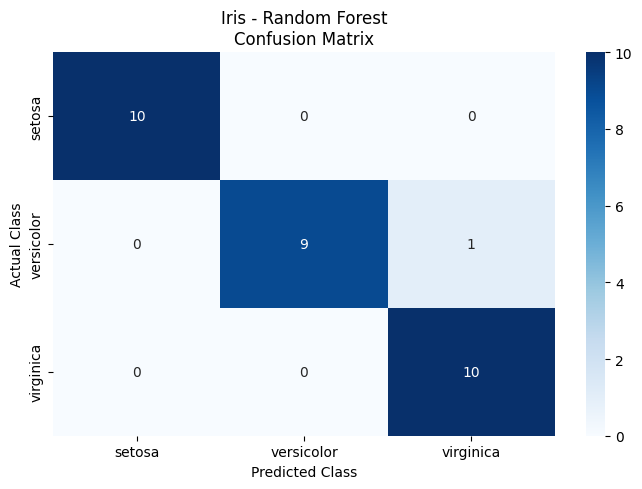

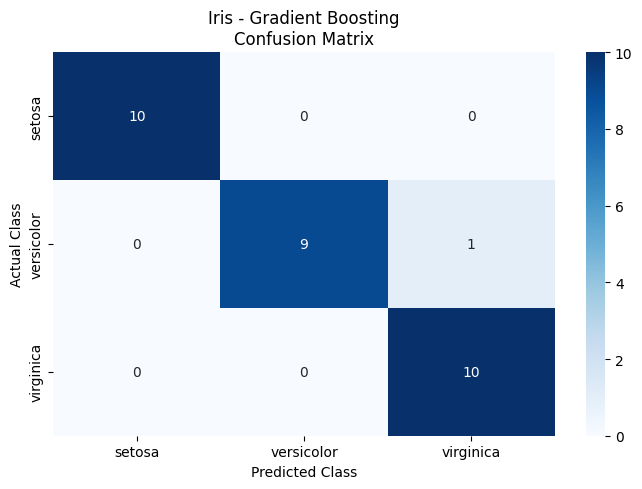

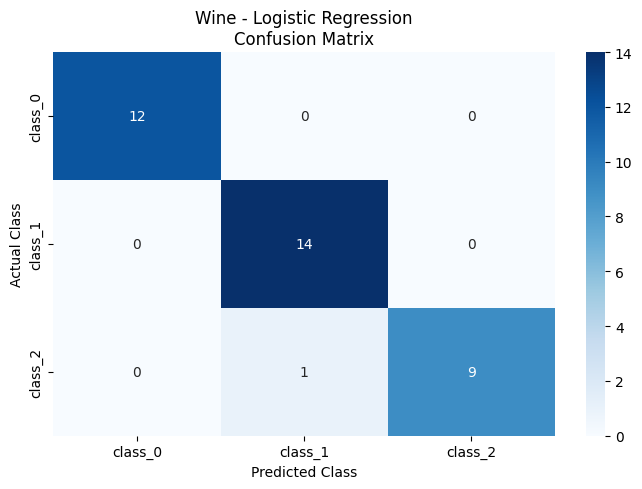

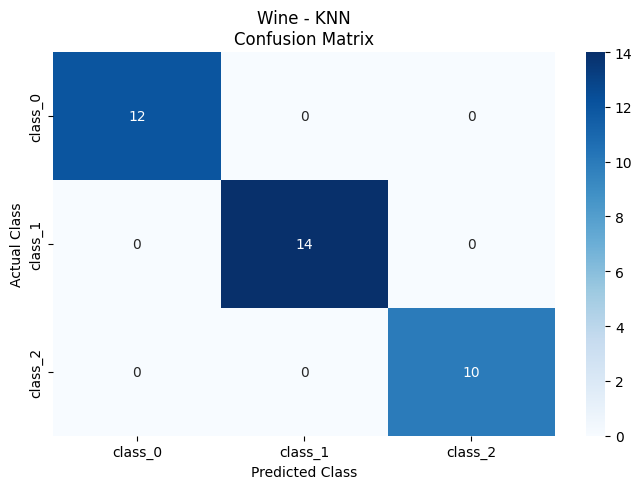

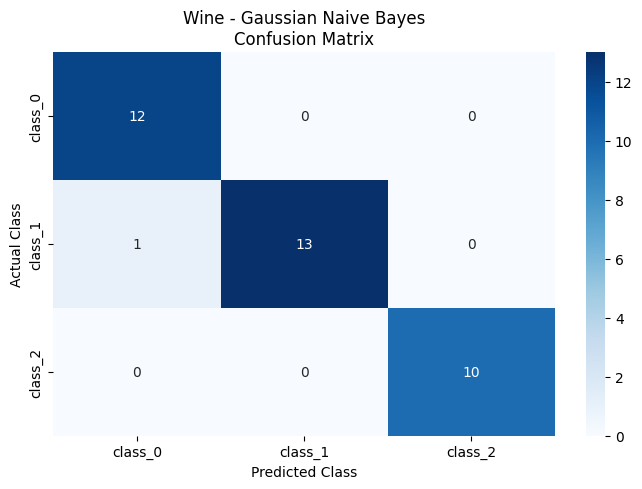

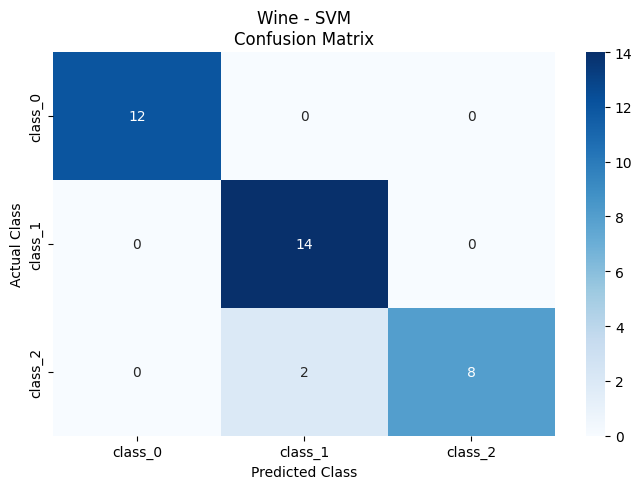

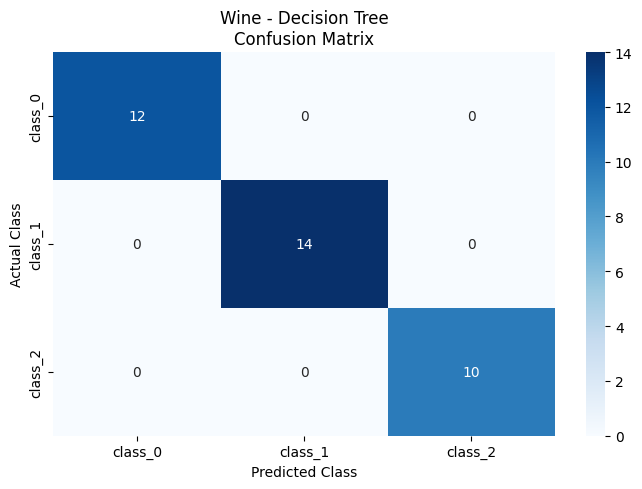

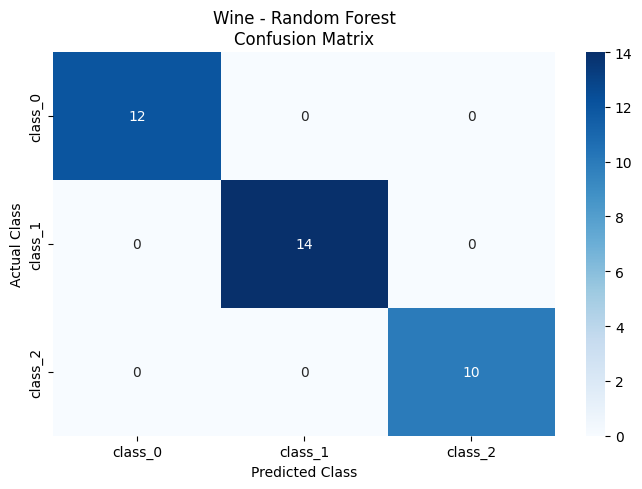

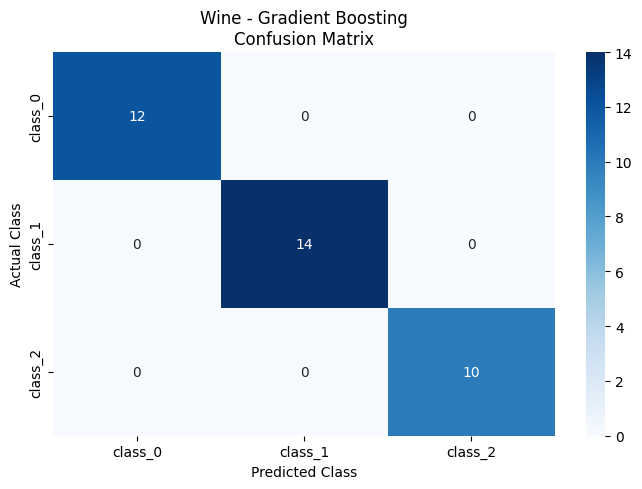

In [16]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

for dataset_name, dataset in datasets.items():

    y_test = data_splits[dataset_name]["y_test"]

    for model_name in models:

        key = (
            f"{dataset_name}_{model_name}"
        )

        y_pred = predictions[key]

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        plt.figure(
            figsize=(7, 5)
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=dataset.target_names,
            yticklabels=dataset.target_names
        )

        plt.title(
            f"{dataset_name} - {model_name}\n"
            "Confusion Matrix"
        )

        plt.xlabel(
            "Predicted Class"
        )

        plt.ylabel(
            "Actual Class"
        )

        plt.tight_layout()

        filename = (
            f"/kaggle/working/results/"
            f"confusion_matrices/"
            f"{dataset_name}_"
            f"{model_name.replace(' ', '_')}.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()

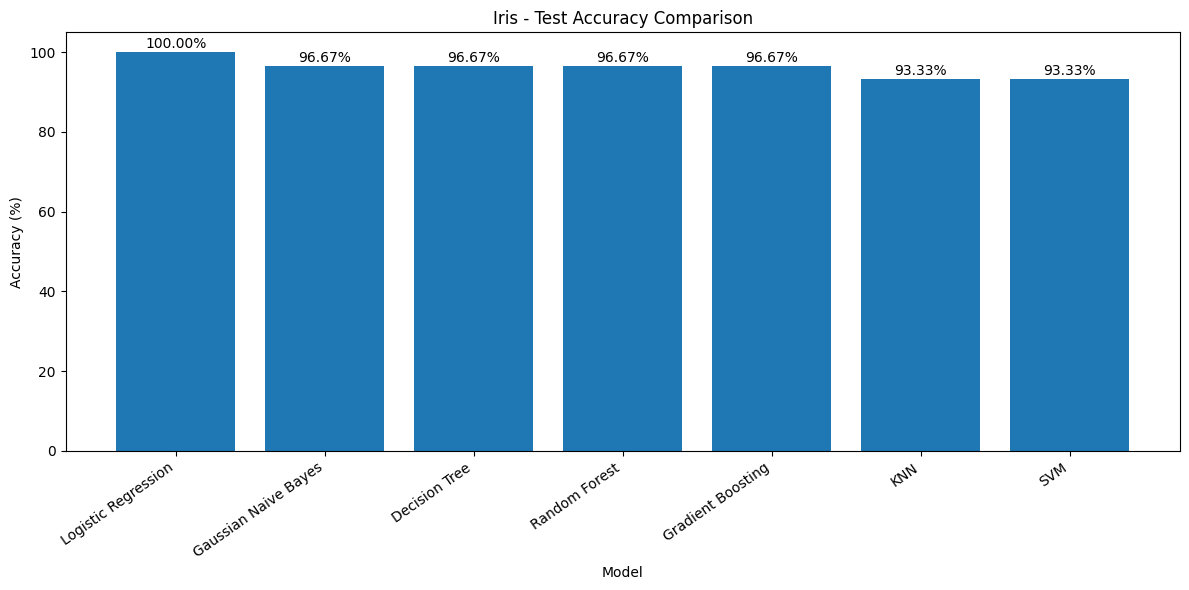

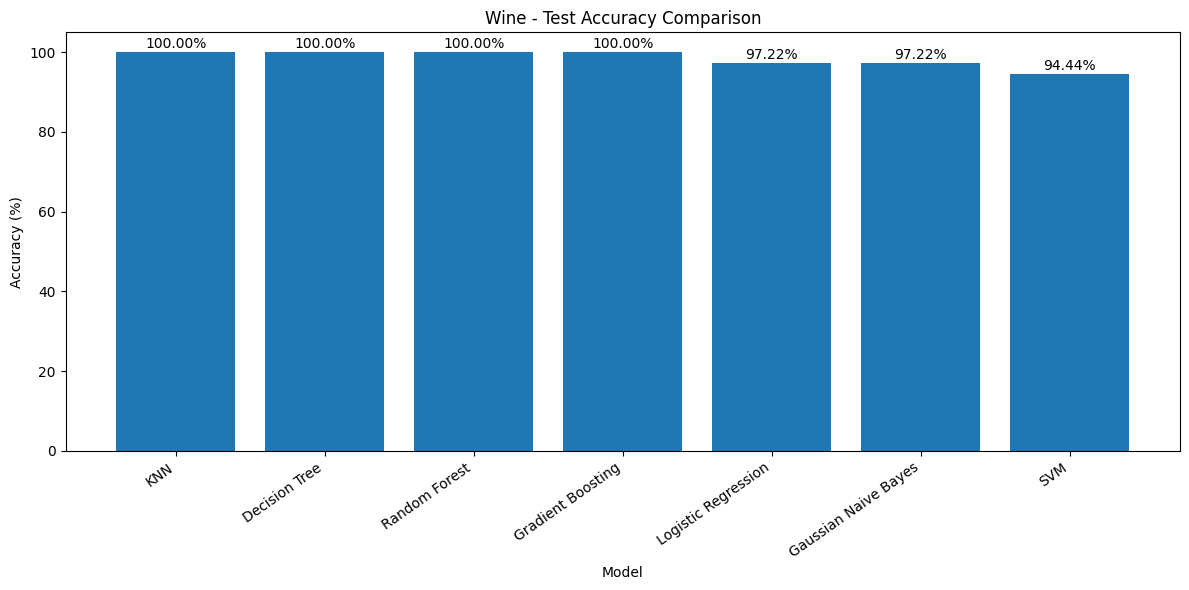

In [17]:
# ============================================================
# ACCURACY COMPARISON
# ============================================================

for dataset_name in datasets:

    temp = results_df[
        results_df["Dataset"] == dataset_name
    ].sort_values(
        "Test Accuracy",
        ascending=False
    )

    plt.figure(
        figsize=(12, 6)
    )

    bars = plt.bar(
        temp["Model"],
        temp["Test Accuracy"] * 100
    )

    plt.title(
        f"{dataset_name} - Test Accuracy Comparison"
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.ylim(
        0,
        105
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() +
            bar.get_width() / 2,

            height + 1,

            f"{height:.2f}%",

            ha="center"
        )

    plt.tight_layout()

    plt.show()

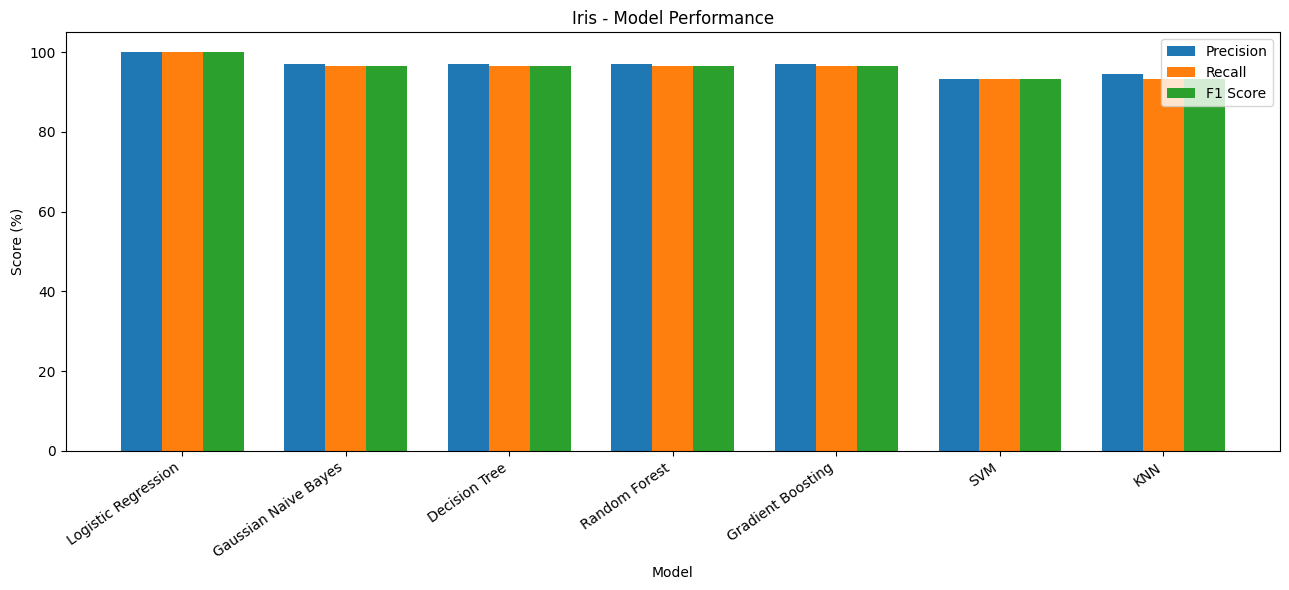

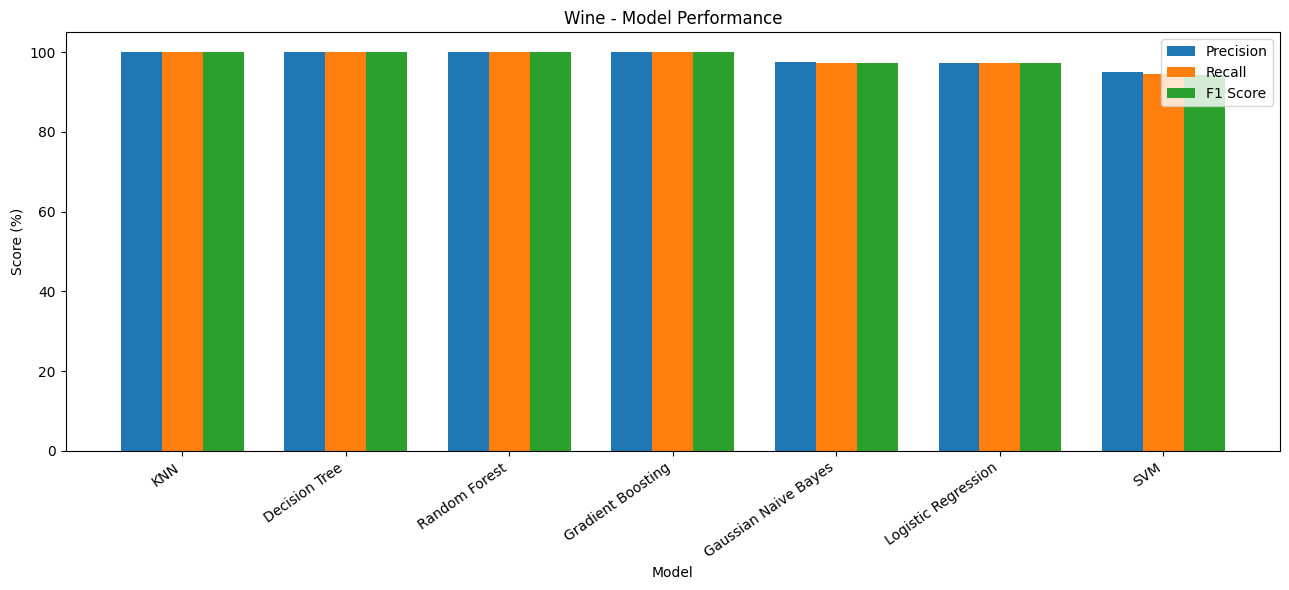

In [18]:
# ============================================================
# PRECISION / RECALL / F1 COMPARISON
# ============================================================

for dataset_name in datasets:

    temp = results_df[
        results_df["Dataset"] == dataset_name
    ].copy()

    temp = temp.sort_values(
        "F1 Score",
        ascending=False
    )

    metrics = [
        "Precision",
        "Recall",
        "F1 Score"
    ]

    x = np.arange(
        len(temp)
    )

    width = 0.25

    plt.figure(
        figsize=(13, 6)
    )

    for i, metric in enumerate(metrics):

        plt.bar(
            x + i * width,
            temp[metric] * 100,
            width,
            label=metric
        )

    plt.title(
        f"{dataset_name} - Model Performance"
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Score (%)"
    )

    plt.xticks(
        x + width,
        temp["Model"],
        rotation=35,
        ha="right"
    )

    plt.ylim(
        0,
        105
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

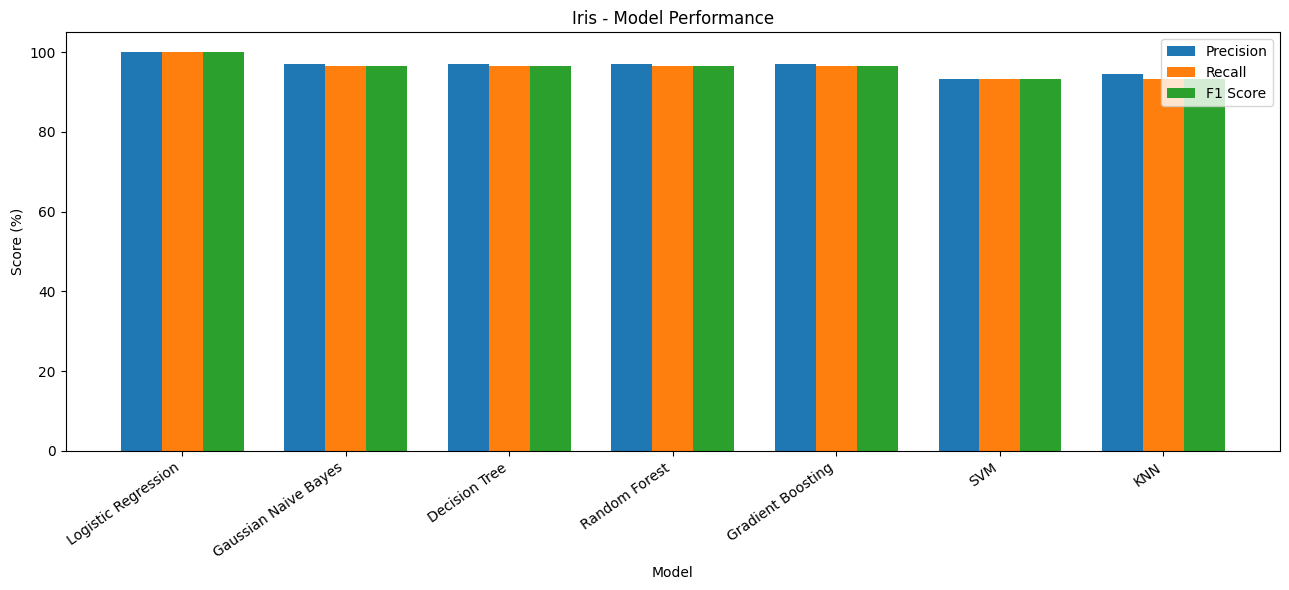

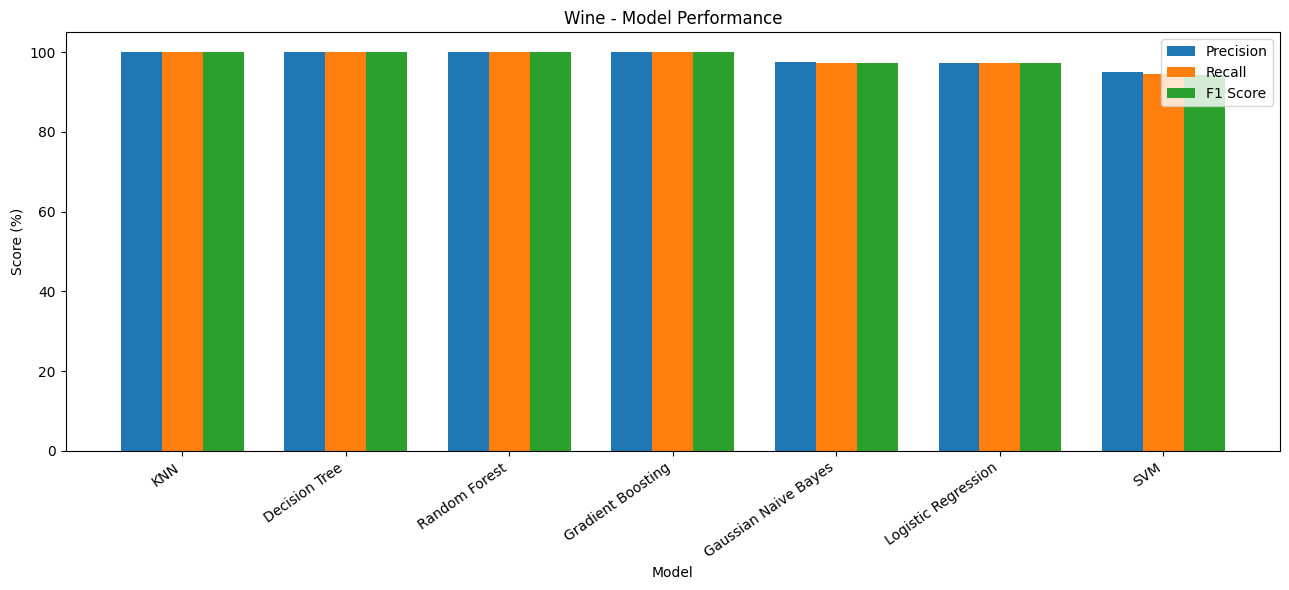

In [19]:
# ============================================================
# PRECISION / RECALL / F1 COMPARISON
# ============================================================

for dataset_name in datasets:

    temp = results_df[
        results_df["Dataset"] == dataset_name
    ].copy()

    temp = temp.sort_values(
        "F1 Score",
        ascending=False
    )

    metrics = [
        "Precision",
        "Recall",
        "F1 Score"
    ]

    x = np.arange(
        len(temp)
    )

    width = 0.25

    plt.figure(
        figsize=(13, 6)
    )

    for i, metric in enumerate(metrics):

        plt.bar(
            x + i * width,
            temp[metric] * 100,
            width,
            label=metric
        )

    plt.title(
        f"{dataset_name} - Model Performance"
    )

    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Score (%)"
    )

    plt.xticks(
        x + width,
        temp["Model"],
        rotation=35,
        ha="right"
    )

    plt.ylim(
        0,
        105
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

In [20]:
# ============================================================
# BEST MODEL FOR EACH DATASET
# ============================================================

best_model_summary = []

for dataset_name in datasets:

    temp = results_df[
        results_df["Dataset"] == dataset_name
    ]

    best_row = temp.loc[
        temp["Test Accuracy"].idxmax()
    ]

    best_model_summary.append(
        best_row
    )

    print("\n")
    print("=" * 70)
    print(f"BEST MODEL: {dataset_name}")
    print("=" * 70)

    print(
        "Model:",
        best_row["Model"]
    )

    print(
        "CV Accuracy:",
        f"{best_row['CV Accuracy'] * 100:.2f}%"
    )

    print(
        "Test Accuracy:",
        f"{best_row['Test Accuracy'] * 100:.2f}%"
    )

    print(
        "Precision:",
        f"{best_row['Precision'] * 100:.2f}%"
    )

    print(
        "Recall:",
        f"{best_row['Recall'] * 100:.2f}%"
    )

    print(
        "F1 Score:",
        f"{best_row['F1 Score'] * 100:.2f}%"
    )


best_models_df = pd.DataFrame(
    best_model_summary
)

display(
    best_models_df.style.format({
        "CV Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)



BEST MODEL: Iris
Model: Logistic Regression
CV Accuracy: 96.67%
Test Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


BEST MODEL: Wine
Model: KNN
CV Accuracy: 97.88%
Test Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%


,Dataset,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Iris,Logistic Regression,96.67%,100.00%,100.00%,100.00%,100.00%
8,Wine,KNN,97.88%,100.00%,100.00%,100.00%,100.00%




Iris - Decision Tree - GINI
CV Accuracy: 95.83%
Test Accuracy: 96.67%
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


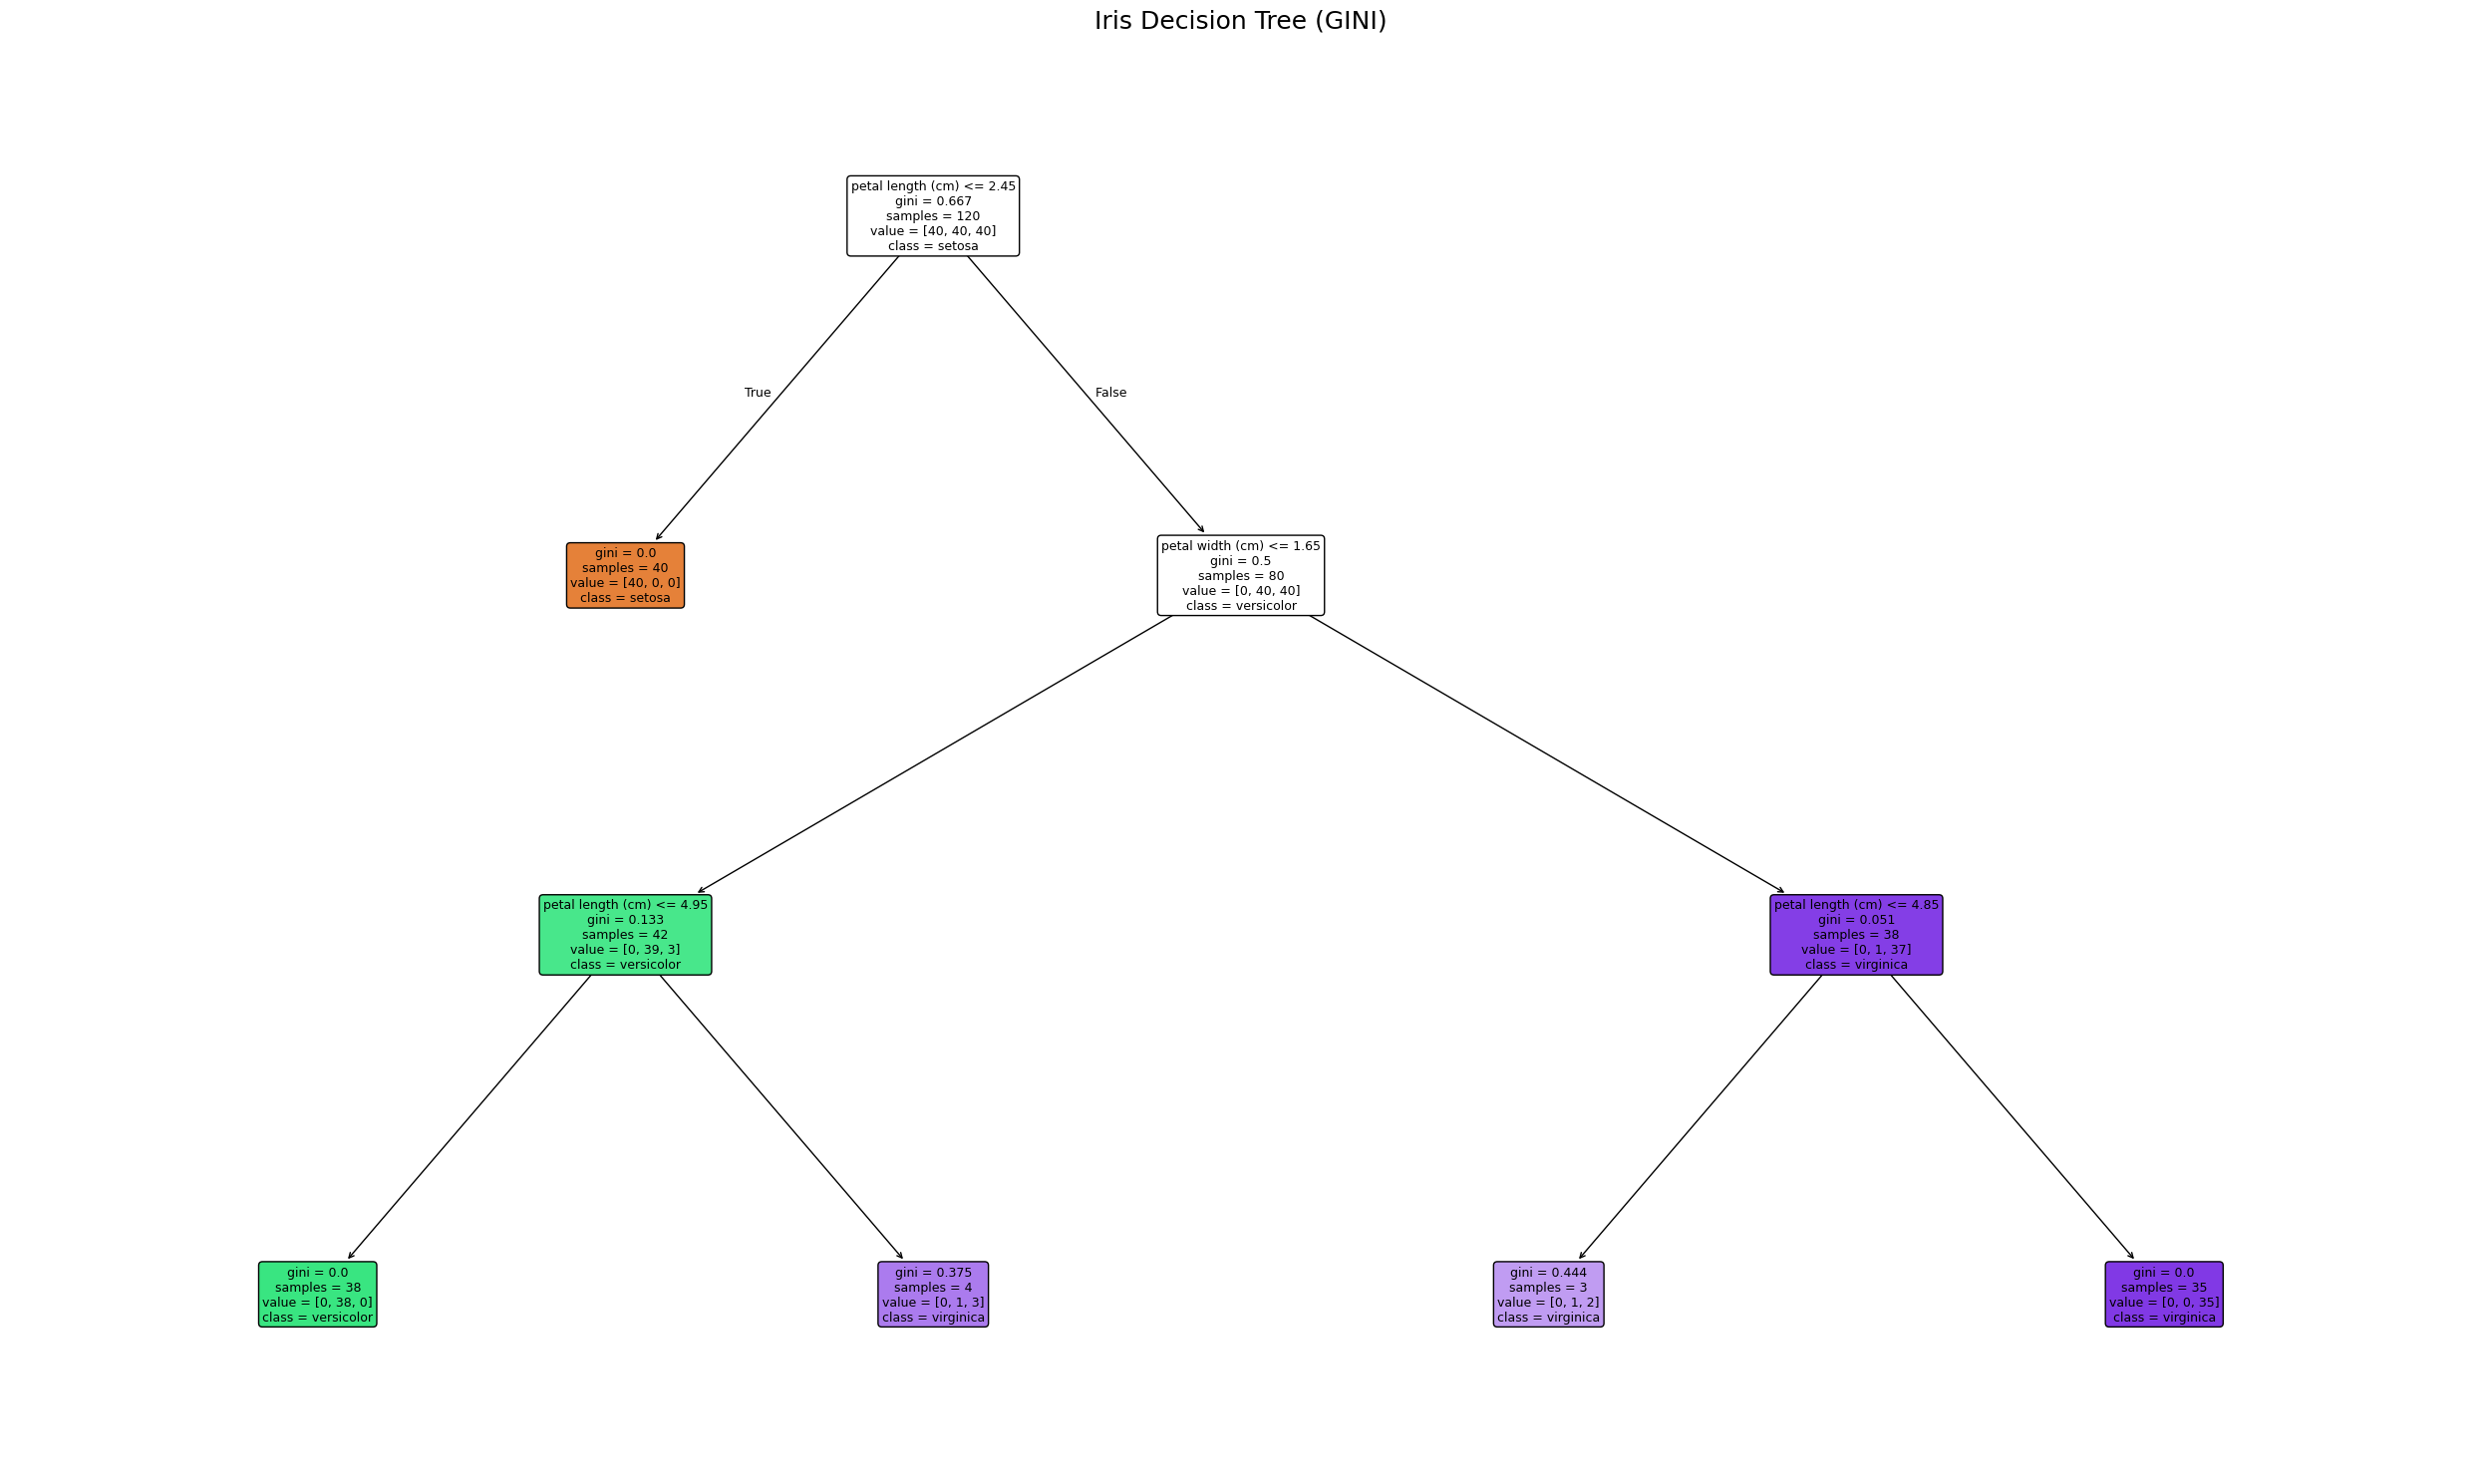



Iris - Decision Tree - ENTROPY
CV Accuracy: 95.83%
Test Accuracy: 96.67%
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


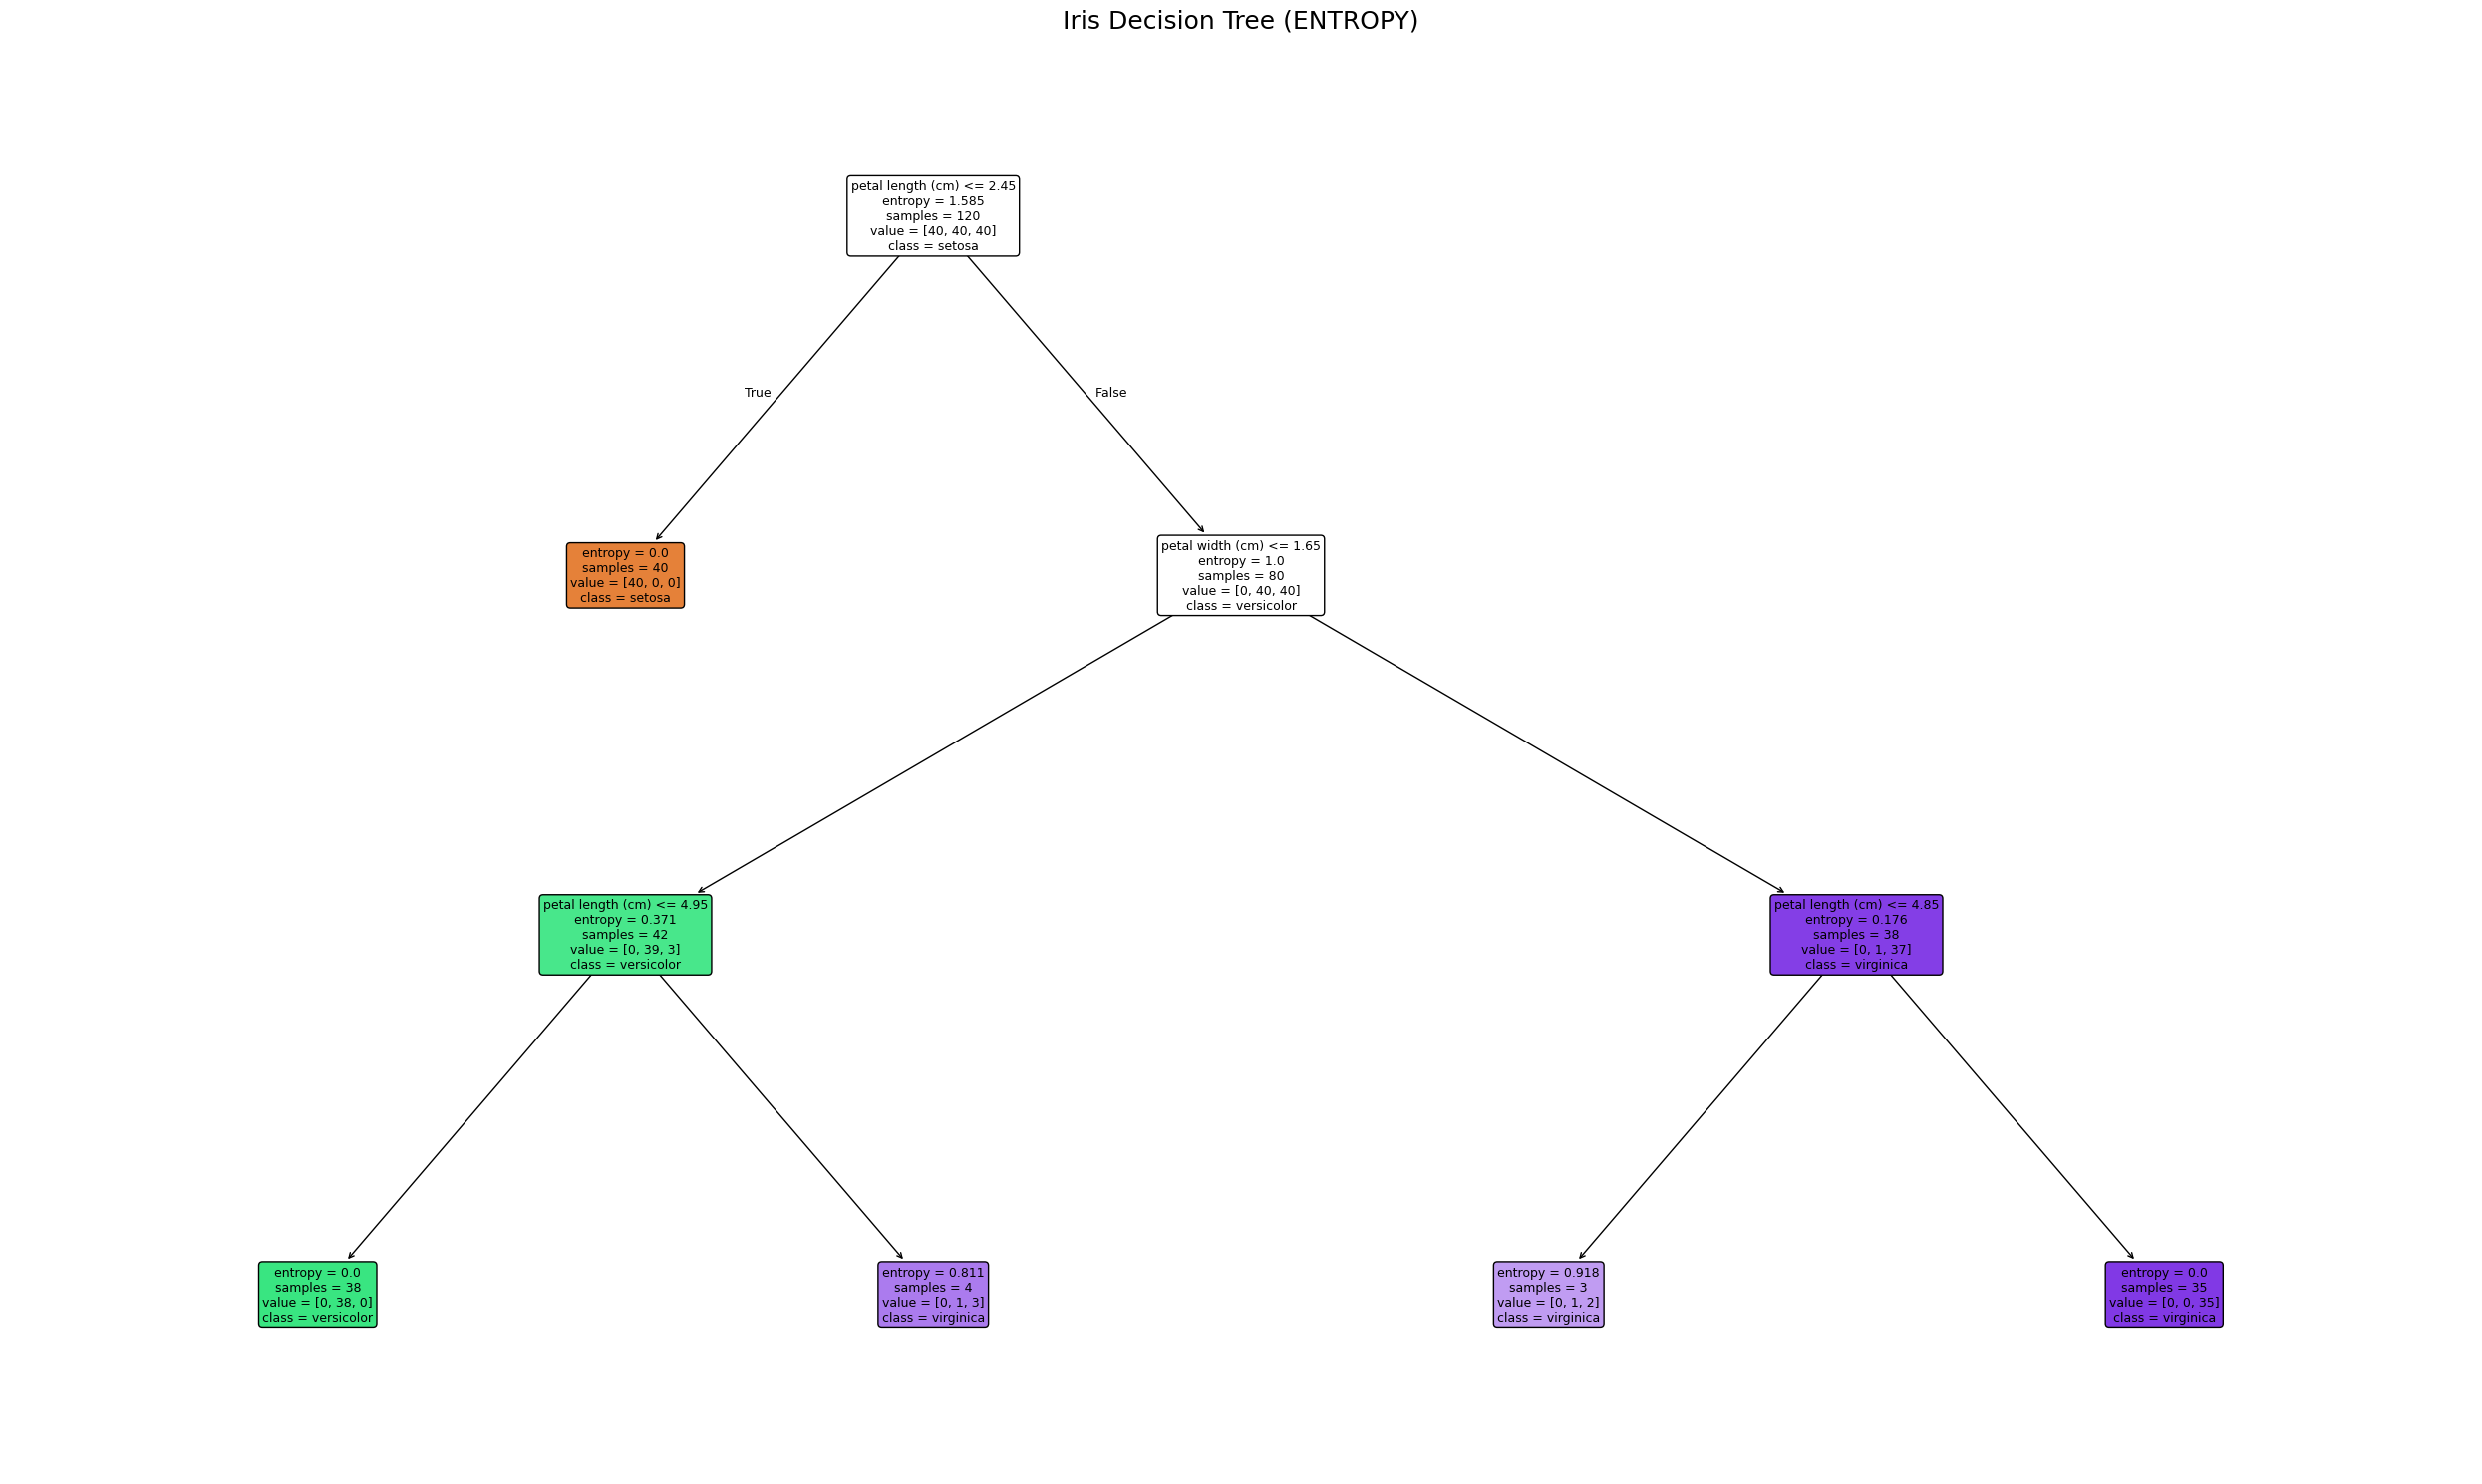



Wine - Decision Tree - GINI
CV Accuracy: 90.25%
Test Accuracy: 100.00%
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


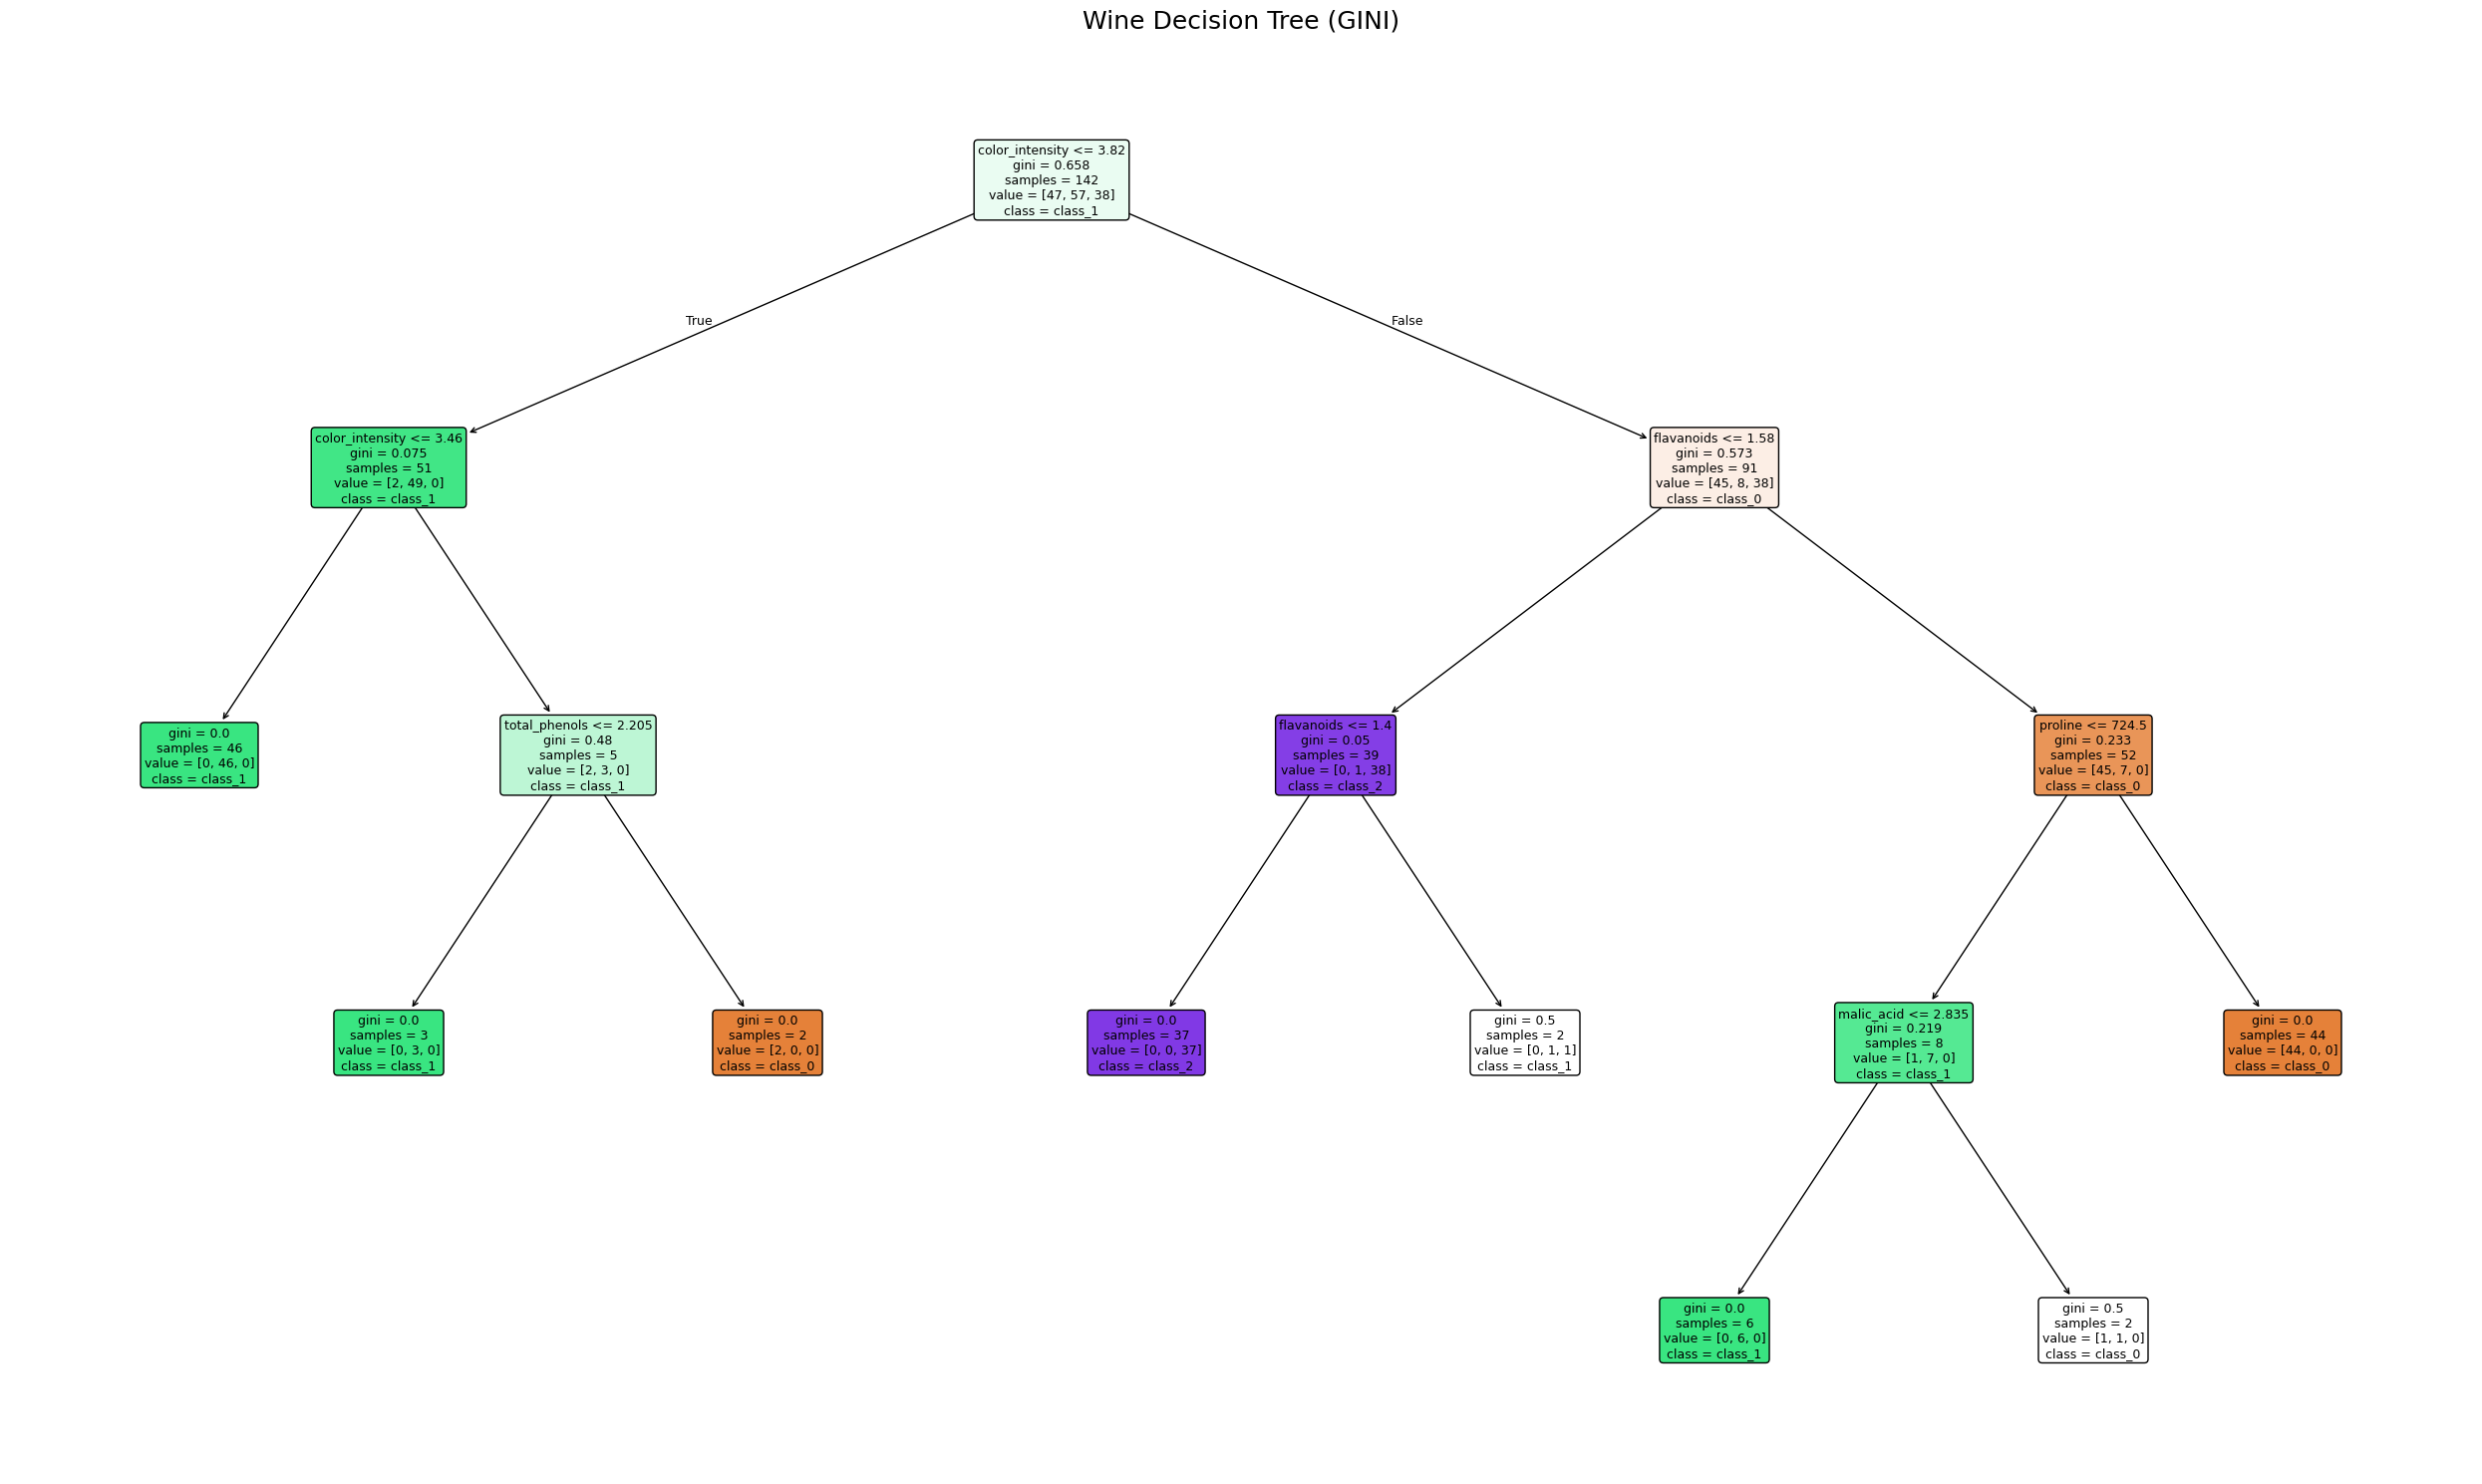



Wine - Decision Tree - ENTROPY
CV Accuracy: 89.51%
Test Accuracy: 97.22%
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


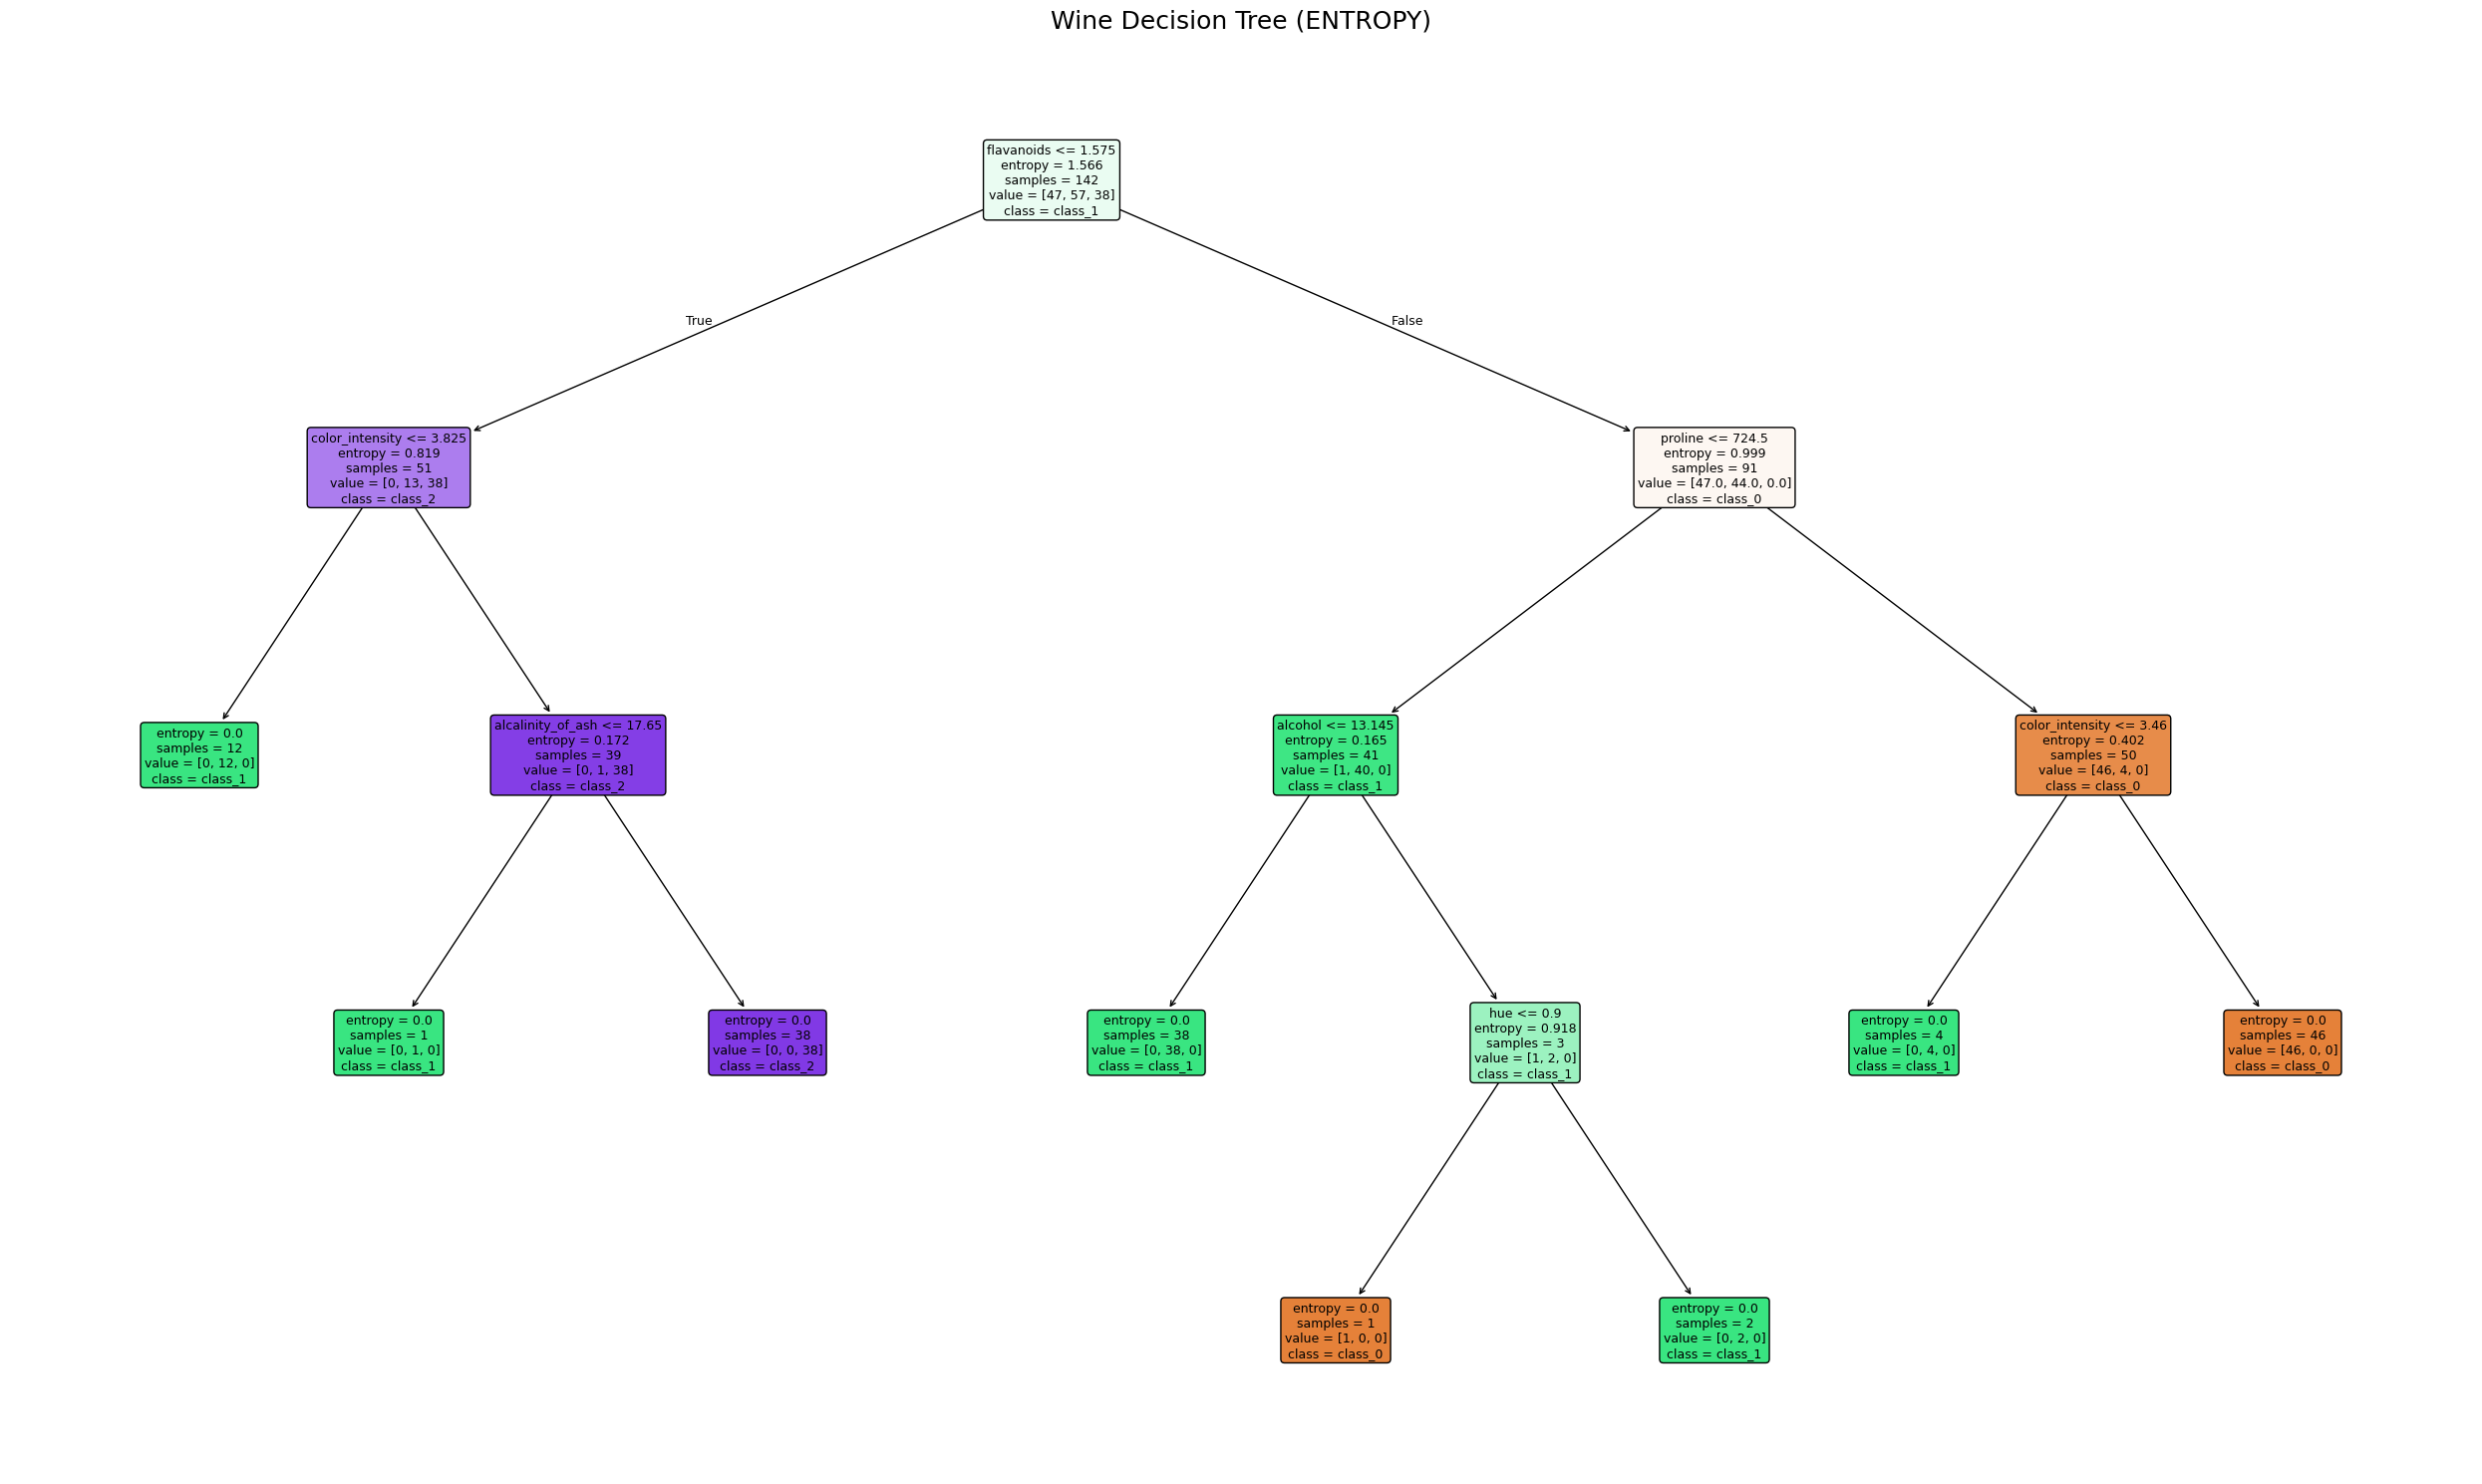

In [21]:
# ============================================================
# DECISION TREE - GINI VS ENTROPY
# ============================================================

tree_results = []

for dataset_name, dataset in datasets.items():

    X_train = data_splits[dataset_name]["X_train"]
    X_test = data_splits[dataset_name]["X_test"]

    y_train = data_splits[dataset_name]["y_train"]
    y_test = data_splits[dataset_name]["y_test"]

    for criterion in ["gini", "entropy"]:

        print("\n")
        print("=" * 70)
        print(
            f"{dataset_name} - "
            f"Decision Tree - {criterion.upper()}"
        )
        print("=" * 70)

        tree_grid = GridSearchCV(

            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            ),

            {
                "criterion": [criterion],

                "max_depth": [
                    None,
                    2,
                    3,
                    4,
                    5,
                    6,
                    8,
                    10
                ],

                "min_samples_split": [
                    2,
                    5,
                    10
                ],

                "min_samples_leaf": [
                    1,
                    2,
                    4
                ]
            },

            cv=cv,

            scoring="accuracy",

            n_jobs=-1
        )

        tree_grid.fit(
            X_train,
            y_train
        )

        best_tree = (
            tree_grid.best_estimator_
        )

        y_pred = best_tree.predict(
            X_test
        )

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted"
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted"
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )

        tree_results.append({

            "Dataset":
                dataset_name,

            "Criterion":
                criterion,

            "CV Accuracy":
                tree_grid.best_score_,

            "Test Accuracy":
                accuracy,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1 Score":
                f1,

            "Parameters":
                tree_grid.best_params_
        })

        print(
            "CV Accuracy:",
            f"{tree_grid.best_score_ * 100:.2f}%"
        )

        print(
            "Test Accuracy:",
            f"{accuracy * 100:.2f}%"
        )

        print(
            "Best Parameters:",
            tree_grid.best_params_
        )

        # ----------------------------------------------------
        # Plot tree
        # ----------------------------------------------------

        plt.figure(
            figsize=(25, 15)
        )

        plot_tree(

            best_tree,

            feature_names=dataset.feature_names,

            class_names=dataset.target_names,

            filled=True,

            rounded=True,

            fontsize=9
        )

        plt.title(
            f"{dataset_name} Decision Tree "
            f"({criterion.upper()})",
            fontsize=18
        )

        plt.tight_layout()

        filename = (
            f"/kaggle/working/results/"
            f"decision_trees/"
            f"{dataset_name}_"
            f"Decision_Tree_"
            f"{criterion.capitalize()}.png"
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        plt.close()


tree_results_df = pd.DataFrame(
    tree_results
)

In [22]:
# ============================================================
# DECISION TREE RESULTS
# ============================================================

display(
    tree_results_df.style.format({
        "CV Accuracy": "{:.2%}",
        "Test Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}"
    })
)

,Dataset,Criterion,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score,Parameters
0,Iris,gini,95.83%,96.67%,96.97%,96.67%,96.66%,"{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}"
1,Iris,entropy,95.83%,96.67%,96.97%,96.67%,96.66%,"{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}"
2,Wine,gini,90.25%,100.00%,100.00%,100.00%,100.00%,"{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}"
3,Wine,entropy,89.51%,97.22%,97.41%,97.22%,97.20%,"{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}"




Iris - Random Forest Feature Importance


,Feature,Importance
2,petal length (cm),0.459684
3,petal width (cm),0.416255
0,sepal length (cm),0.114403
1,sepal width (cm),0.009658


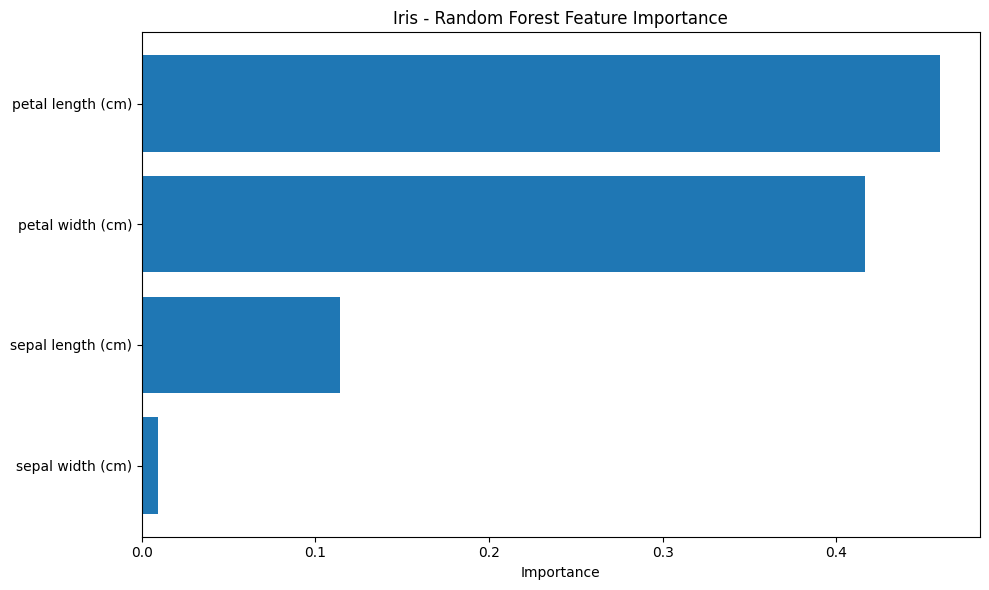



Wine - Random Forest Feature Importance


,Feature,Importance
9,color_intensity,0.187580
6,flavanoids,0.159561
12,proline,0.146799
0,alcohol,0.117913
10,hue,0.101538
11,od280/od315_of_diluted_wines,0.096301
5,total_phenols,0.041514
4,magnesium,0.040131
1,malic_acid,0.033894
3,alcalinity_of_ash,0.025471


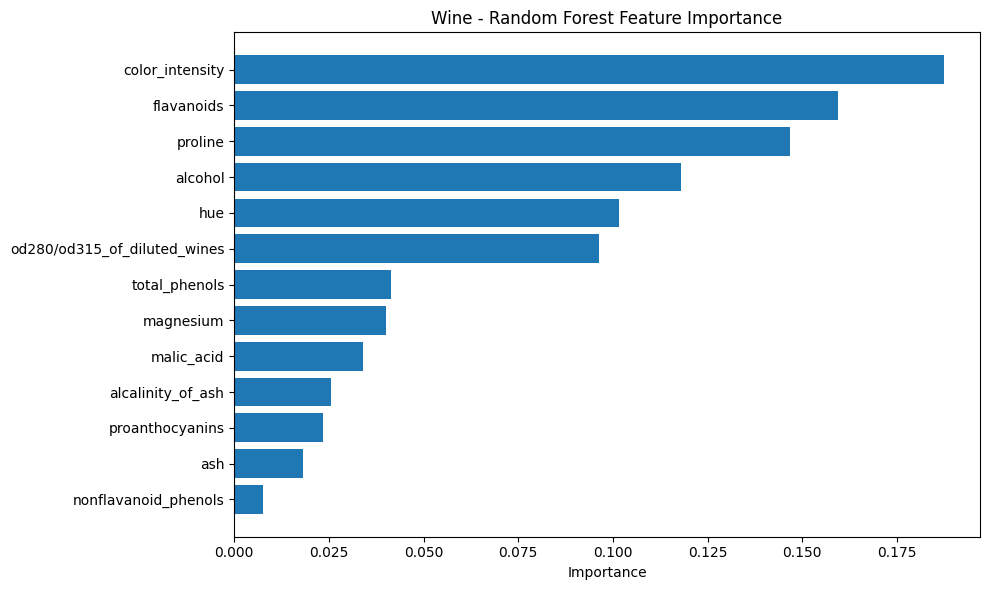

In [23]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

for dataset_name, dataset in datasets.items():

    key = (
        f"{dataset_name}_Random Forest"
    )

    rf_model = best_models[key]

    importances = (
        rf_model.feature_importances_
    )

    importance_df = pd.DataFrame({

        "Feature":
            dataset.feature_names,

        "Importance":
            importances

    }).sort_values(
        "Importance",
        ascending=False
    )

    print("\n")
    print("=" * 70)
    print(
        f"{dataset_name} - "
        "Random Forest Feature Importance"
    )
    print("=" * 70)

    display(
        importance_df
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.title(
        f"{dataset_name} - "
        "Random Forest Feature Importance"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

In [24]:
# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "/kaggle/working/results/"
    "final_model_results.csv",
    index=False
)

grid_results_df.to_csv(
    "/kaggle/working/results/"
    "grid_search_results.csv",
    index=False
)

tree_results_df.to_csv(
    "/kaggle/working/results/"
    "decision_tree_results.csv",
    index=False
)

print("All CSV results saved successfully.")

All CSV results saved successfully.


In [25]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

for dataset_name in datasets:

    temp = results_df[
        results_df["Dataset"] == dataset_name
    ]

    temp = temp.sort_values(
        "Test Accuracy",
        ascending=False
    )

    print(f"\n{dataset_name}")
    print("-" * 50)

    display(
        temp[
            [
                "Model",
                "CV Accuracy",
                "Test Accuracy",
                "Precision",
                "Recall",
                "F1 Score"
            ]
        ].style.format({
            "CV Accuracy": "{:.2%}",
            "Test Accuracy": "{:.2%}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1 Score": "{:.2%}"
        })
    )

print("\n")
print("=" * 80)
print("PROJECT COMPLETE")
print("=" * 80)



FINAL PROJECT SUMMARY

Iris
--------------------------------------------------


,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,96.67%,100.00%,100.00%,100.00%,100.00%
2,Gaussian Naive Bayes,95.00%,96.67%,96.97%,96.67%,96.66%
4,Decision Tree,95.83%,96.67%,96.97%,96.67%,96.66%
5,Random Forest,96.67%,96.67%,96.97%,96.67%,96.66%
6,Gradient Boosting,96.67%,96.67%,96.97%,96.67%,96.66%
1,KNN,96.67%,93.33%,94.44%,93.33%,93.27%
3,SVM,97.50%,93.33%,93.33%,93.33%,93.33%



Wine
--------------------------------------------------


,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
8,KNN,97.88%,100.00%,100.00%,100.00%,100.00%
11,Decision Tree,90.25%,100.00%,100.00%,100.00%,100.00%
12,Random Forest,97.91%,100.00%,100.00%,100.00%,100.00%
13,Gradient Boosting,97.19%,100.00%,100.00%,100.00%,100.00%
7,Logistic Regression,97.91%,97.22%,97.41%,97.22%,97.20%
9,Gaussian Naive Bayes,97.22%,97.22%,97.44%,97.22%,97.23%
10,SVM,99.31%,94.44%,95.14%,94.44%,94.32%




PROJECT COMPLETE
